# 2. Network Analysis: Audio-Based Exploration of Audio Communities

In [ ]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import powerlaw
from fa2_modified import ForceAtlas2
import seaborn as sns
from collections import Counter
from matplotlib.patches import Patch   
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import random
import itertools
import warnings
warnings.filterwarnings('ignore')  
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community.quality import modularity
from sklearn.decomposition import PCA

# Load the graph

In [ ]:
GEXF_PATH_TRACK = "spotify_knn_k10_removed_same_tracks.gexf"   
# Load the graph from GEXF file
G = nx.read_gexf(GEXF_PATH_TRACK)
print("Raw graph loaded:")
print("  Nodes:", G.number_of_nodes())
print("  Edges:", G.number_of_edges())
print("  Directed:", G.is_directed())

# If the file is directed, convert to undirected
if G.is_directed():
    G = G.to_undirected()

# Remove self loops 
print("Self-loops before removal:", nx.number_of_selfloops(G))
G.remove_edges_from(nx.selfloop_edges(G))
print("Self-loops after removal:", nx.number_of_selfloops(G))

print("\nWorking graph (undirected):")
print("  Nodes:", G.number_of_nodes())
print("  Edges:", G.number_of_edges())
print("  Is directed:", G.is_directed())

Raw graph loaded:
  Nodes: 73403
  Edges: 498303
  Directed: False
Self-loops before removal: 73403
Self-loops after removal: 0

Working graph (undirected):
  Nodes: 73403
  Edges: 424900
  Is directed: False


The Spotify track–track similarity graph is loaded from the GEXF file as an undirected network with 73,403 nodes and 498,303 edges, where each node initially carries a self-loop (73,403 self-loops in total). Self-loops are removed because they do not contribute to the relational structure between distinct tracks and would distort degree-based measures. The resulting working graph is a simple undirected network with 73,403 nodes and 424,900 edges, which serves as the basis for all subsequent network analysis.


# Giant weakly connected component

In [3]:
# Analyze connected components
components = list(nx.connected_components(G))
components_sizes = sorted([len(c) for c in components], reverse=True)

print("\nConnected components:")
print("  Number of components:", len(components))
print("  Largest components (sizes):", components_sizes[:10])

# Extract the giant component
giant_nodes = max(components, key=len)
G_gc = G.subgraph(giant_nodes).copy()

print("\nGiant Component:")
print("  N (nodes):", G_gc.number_of_nodes())
print("  M (edges):", G_gc.number_of_edges())


Connected components:
  Number of components: 1
  Largest components (sizes): [73403]

Giant Component:
  N (nodes): 73403
  M (edges): 424900


The Spotify track–track similarity graph is loaded from the GEXF file as an undirected network with 73,403 nodes and 498,303 edges, where each node initially carries a self-loop (73,403 self-loops in total). Self-loops are removed because they do not contribute to the relational structure between distinct tracks and would distort degree-based measures. The resulting working graph is a simple undirected network with 73,403 nodes and 424,900 edges, which serves as the basis for all subsequent network analysis.


# Basic Structural metrics

In [4]:
# Compute basic metrics for the giant component
N = G_gc.number_of_nodes()
M = G_gc.number_of_edges()
# Average degree <k>
avg_degree = 2 * M / N
# Density
density = nx.density(G_gc)
# Degree statistics
degrees = dict(G_gc.degree())
deg_values = np.array(list(degrees.values()))
# Print metrics
print("\nBasic metrics (giant component):")
print(f"  Average degree <k>: {avg_degree:.4f}")
print(f"  Density: {density:.6f}")

print("\nDegree statistics:")
print("  min degree:", deg_values.min())
print("  max degree:", deg_values.max())
print("  mean degree:", deg_values.mean())
print("  median degree:", np.median(deg_values))


Basic metrics (giant component):
  Average degree <k>: 11.5772
  Density: 0.000158

Degree statistics:
  min degree: 9
  max degree: 23
  mean degree: 11.577183493862648
  median degree: 11.0


The giant component of the track similarity network contains 73,403 nodes and 424,900 edges, with an average degree of approximately 11.58 and a density of 0.000158, indicating a large but highly sparse graph. Node degrees range from 9 to 23, with a mean of 11.58 and a median of 11, revealing a narrow degree distribution in which most tracks have similar numbers of neighbours. This relatively homogeneous connectivity suggests the absence of extreme hubs and provides a baseline for interpreting more detailed structural features such as clustering, assortativity, and community structure.


# Degree Distribution & Scale-Free Check

(Barabási: P(k), log–log plot, possible power-law)

In [5]:
# Degree statistics
degrees = dict(G_gc.degree())
deg_values = np.array(list(degrees.values()))
deg_counts = np.bincount(deg_values)
nonzero = deg_counts > 0
k_vals = np.arange(len(deg_counts))



### Linear-scale histogram

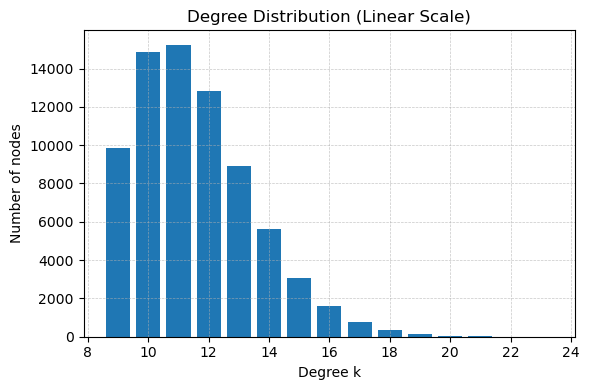

In [6]:
plt.figure(figsize=(6, 4))
plt.bar(k_vals[nonzero],
        deg_counts[nonzero],
        width=0.8,
        align="center")

plt.xlabel("Degree k")
plt.ylabel("Number of nodes")
plt.title("Degree Distribution (Linear Scale)")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
plt.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()


The empirical degree distribution is sharply concentrated between degrees 9 and 14, with a clear peak around 11–12 neighbours and a rapidly decaying right tail beyond that range. Only a small fraction of nodes attain degrees above 16, and almost none exceed 20, indicating the absence of extreme hubs or a heavy-tailed pattern. This unimodal, narrow distribution confirms that connectivity in the network is relatively homogeneous, supporting the view that the graph behaves more like a mildly perturbed regular network than a highly heterogeneous, scale-free structure.


### Log–log degree distribution

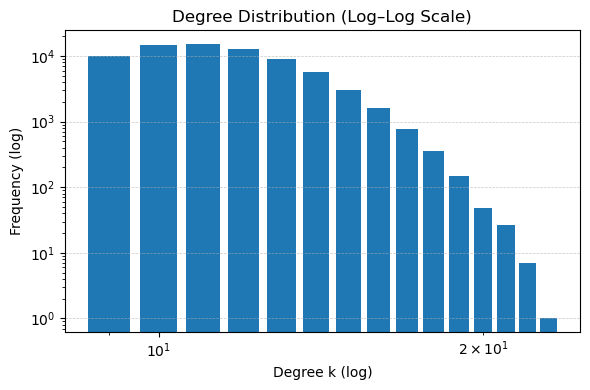

In [7]:
# Plot degree distribution (log–log scale)

deg_values = np.array([d for _, d in G.degree()])
deg_counts = np.bincount(deg_values)
k_vals = np.arange(len(deg_counts))
nonzero = deg_counts > 0

plt.figure(figsize=(6, 4))

# Histogram
plt.bar(k_vals[nonzero],
        deg_counts[nonzero],
        width=0.8,          
        align="center")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree k (log)")
plt.ylabel("Frequency (log)")
plt.title("Degree Distribution (Log–Log Scale)")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()


On log–log axes, the degree distribution shows a rapid decline in frequency as degree increases from 9 to the low 20s, with no extended linear region. A genuine power-law or scale-free network would typically produce an approximately straight line over a wide range of degrees, reflecting a heavy-tailed distribution with many high-degree hubs. The strong curvature and short support observed here therefore indicate that the network does not follow a power-law degree distribution and lacks pronounced hub dominance.


### Power-law fit (Barabási-style)

In [8]:
# Exclude zero degrees 
deg_positive = deg_values[deg_values > 0]
# Fit power-law to degree distribution
fit = powerlaw.Fit(deg_positive, verbose=False)
alpha = fit.power_law.alpha
xmin = fit.power_law.xmin

print("Power-law fit results:")
print(f"  alpha (scaling exponent): {alpha:.4f}")
print(f"  xmin  (minimum k for power-law behaviour): {xmin}")

# Compare power-law vs lognormal 
R, p = fit.distribution_compare('power_law', 'lognormal')
print("\nPower-law vs lognormal comparison:")
print(f"  R = {R:.4f}")
print(f"  p = {p:.4f}")

Power-law fit results:
  alpha (scaling exponent): 180.9704
  xmin  (minimum k for power-law behaviour): 22.0

Power-law vs lognormal comparison:
  R = -0.6987
  p = 0.3519


'nan' in fit cumulative distribution values.
Likely underflow or overflow error: the optimal fit for this distribution gives values that are so extreme that we lack the numerical precision to calculate them.


The power-law fit to the degree sequence returns an estimated scaling exponent alpha ≈ 181 with xmin = 22, which is unrealistically large and based on only a very small number of high-degree nodes. The fitting routine also reports numerical problems (“nan” values in the cumulative distribution), indicating that the optimal parameters lie in an extreme region where the model becomes numerically unstable. A comparison with a lognormal alternative gives R = -0.6987 and p ≈ 0.35, suggesting that the lognormal provides a somewhat better description of the data, although the evidence is not statistically decisive. Taken together, these results indicate that the degree distribution is strongly incompatible with a meaningful power-law model and is better viewed as a thin-tailed distribution without a genuine scale-free regime.


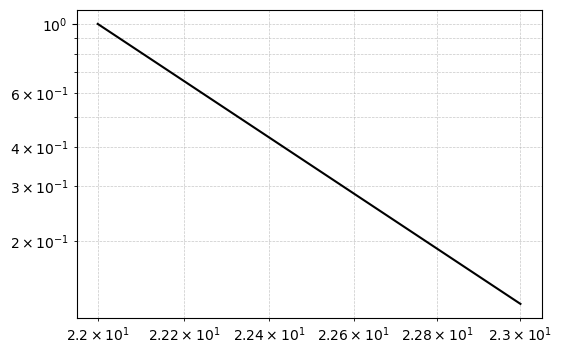

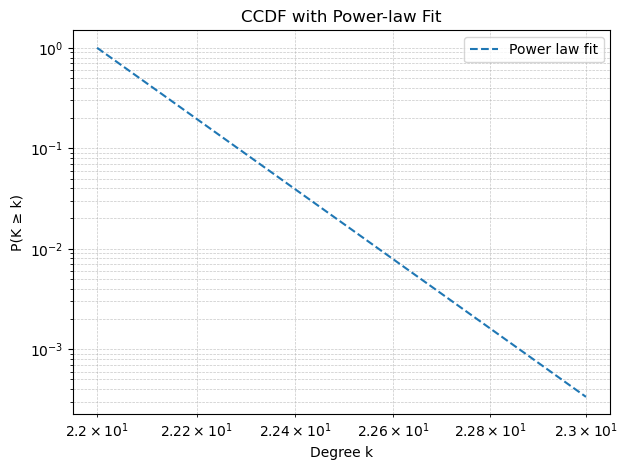

In [9]:
#  plot the fitted CCDF on log–log axes
plt.figure(figsize=(6, 4))
fit.plot_ccdf(label='Data', color='black')
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
fit.power_law.plot_ccdf(label='Power law fit', linestyle='--')
plt.legend()
plt.xlabel('Degree k')
plt.ylabel('P(K ≥ k)')
plt.title('CCDF with Power-law Fit')
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

The complementary cumulative degree distribution (CCDF) on log–log axes shows support only for degrees 22 and 23 above the fitted xmin, so the empirical tail consists of essentially two points. As a result, the fitted power-law CCDF appears as an almost perfect straight line, but this behaviour is purely a consequence of the trivial two-point tail rather than evidence of genuine scale-free structure. The CCDF plot therefore confirms that the data provide no meaningful range over which a power-law model could be reliably evaluated.


# Small-world properties

Converting the multigraph into simple network for all later analysis (clustering, path length, communities, etc.)

In [10]:
# Convert MultiGraph / MultiDiGraph to a simple Graph
G_gc_simple = nx.Graph()

# Copy nodes + attributes
for n, data in G_gc.nodes(data=True):
    G_gc_simple.add_node(n, **data)

# Merge parallel edges: keep the **maximum weight** between any pair
for u, v, data in G_gc.edges(data=True):
    w = data.get("weight", 1.0)
    if G_gc_simple.has_edge(u, v):
        # keep the max weight 
        if w > G_gc_simple[u][v].get("weight", 1.0):
            G_gc_simple[u][v]["weight"] = w
    else:
        G_gc_simple.add_edge(u, v, **data)

# Remove self-loops
G_gc_simple.remove_edges_from(nx.selfloop_edges(G_gc_simple))

print("\nSimple graph created from G_gc:")
print("  Nodes:", G_gc_simple.number_of_nodes())
print("  Edges:", G_gc_simple.number_of_edges())
print("  Is multigraph:", G_gc_simple.is_multigraph())
print("  Is directed:", G_gc_simple.is_directed())


Simple graph created from G_gc:
  Nodes: 73403
  Edges: 424900
  Is multigraph: False
  Is directed: False


In [11]:
# Clustering coefficients
G_sw = G_gc_simple
print("\n[1] Clustering coefficients")
C = nx.average_clustering(G_sw)      # average local clustering
T = nx.transitivity(G_sw)            # global triangle-based clustering

print(f"  Average clustering C: {C:.4f}")
print(f"  Transitivity T:       {T:.4f}")


[1] Clustering coefficients
  Average clustering C: 0.3245
  Transitivity T:       0.3200


The track similarity network displays substantial local cohesion, with an average clustering coefficient of 0.3245 and a global transitivity of 0.3200. These values indicate that if two tracks are each similar to a given third track, there is a relatively high chance that they are also directly similar to one another, forming many closed triangles in the graph. Such levels of clustering are typical of small-world and community-structured networks and already suggest a strong tendency toward tightly knit local groups of tracks.


In [12]:
# Erdős–Rényi random graph baseline with same N, M
print("\n[2] Erdős–Rényi baseline G(N, M) for clustering only")
N = G_sw.number_of_nodes()
M = G_sw.number_of_edges()
rng_seed = 42

G_rand = nx.gnm_random_graph(N, M, seed=rng_seed)

C_rand = nx.average_clustering(G_rand)
T_rand = nx.transitivity(G_rand)

print(f"  C_rand: {C_rand:.4f}")
print(f"  T_rand: {T_rand:.4f}")


[2] Erdős–Rényi baseline G(N, M) for clustering only
  C_rand: 0.0001
  T_rand: 0.0001


The track similarity network shows strong local clustering, with an average clustering coefficient $C = 0.3245$ and a global transitivity $T = 0.3200$. Here, $C$ measures the average fraction of a node’s neighbours that are also connected to each other, while $T$ measures the fraction of all connected triples in the graph that are closed into triangles.

For comparison, an Erdős–Rényi random graph $G(N, M)$ with the same number of nodes and edges has average clustering $C_{\text{rand}} = 0.0001$ and transitivity $T_{\text{rand}} = 0.0001$, several orders of magnitude smaller than the observed values. The ratios $C / C_{\text{rand}}$ and $T / T_{\text{rand}}$ are therefore on the order of $10^3$, indicating that tracks form far more tightly knit local groups than would be expected by chance in a graph with the same size and density. This strong excess of triangles is characteristic of small-world or community-structured networks.


In [13]:
# Small-world-like check (clustering only)
print("\n[3] Clustering ratios (small-world-like indicator)")
print(f"  C / C_rand = {C / C_rand:.2f}")


[3] Clustering ratios (small-world-like indicator)
  C / C_rand = 2304.09


The ratio of empirical to random clustering, $C / C_{\text{rand}} \approx 2304$, quantifies how much more frequently triangles occur in the track similarity network than in an Erdős–Rényi graph with the same size and density. This value indicates that locally cohesive triplets of tracks are more than three orders of magnitude more common than expected under a purely random wiring pattern. Even without an explicit estimate of average path length, such an extreme excess of clustering is characteristic of small-world or strongly modular network organisation.


# Simple visualisation on a graph

In [14]:
# We use the simple graph for plotting
G_plot_base = G_gc_simple

# Sample a subset of nodes for plotting 
np.random.seed(42)
sample_size = min(2000, G_plot_base.number_of_nodes())  # cap at 2000 for better readability
sample_nodes = np.random.choice(list(G_plot_base.nodes()), size=sample_size, replace=False)

G_sample = G_plot_base.subgraph(sample_nodes).copy()
print(f"Sampled subgraph: {G_sample.number_of_nodes()} nodes, {G_sample.number_of_edges()} edges")


Sampled subgraph: 2000 nodes, 301 edges


In [15]:
# Node size = degree in the sampled subgraph
deg_sample = dict(G_sample.degree())
deg_vals = np.array(list(deg_sample.values()))
min_deg, max_deg = deg_vals.min(), deg_vals.max()

min_size, max_size = 50, 600
if max_deg == min_deg:
    node_sizes = [300] * len(deg_sample)
else:
    node_sizes = [
        min_size + (max_size - min_size) * (d - min_deg) / (max_deg - min_deg)
        for d in deg_sample.values()
    ]

In [16]:
# Node colour = genre 
genres = []
has_genre = "genre" in next(iter(G_sample.nodes(data=True)))[1]

if has_genre:
    for n in G_sample.nodes():
        genres.append(G_sample.nodes[n].get("genre", "Unknown"))
    # Map genres to integers for colouring
    unique_genres = {g: i for i, g in enumerate(sorted(set(genres)))}
    node_colors = [unique_genres[g] for g in genres]
    color_label = "Genre (encoded)"
else:
    node_colors = list(deg_sample.values())
    color_label = "Degree"

print(f"Colouring nodes by: {color_label}")

Colouring nodes by: Genre (encoded)


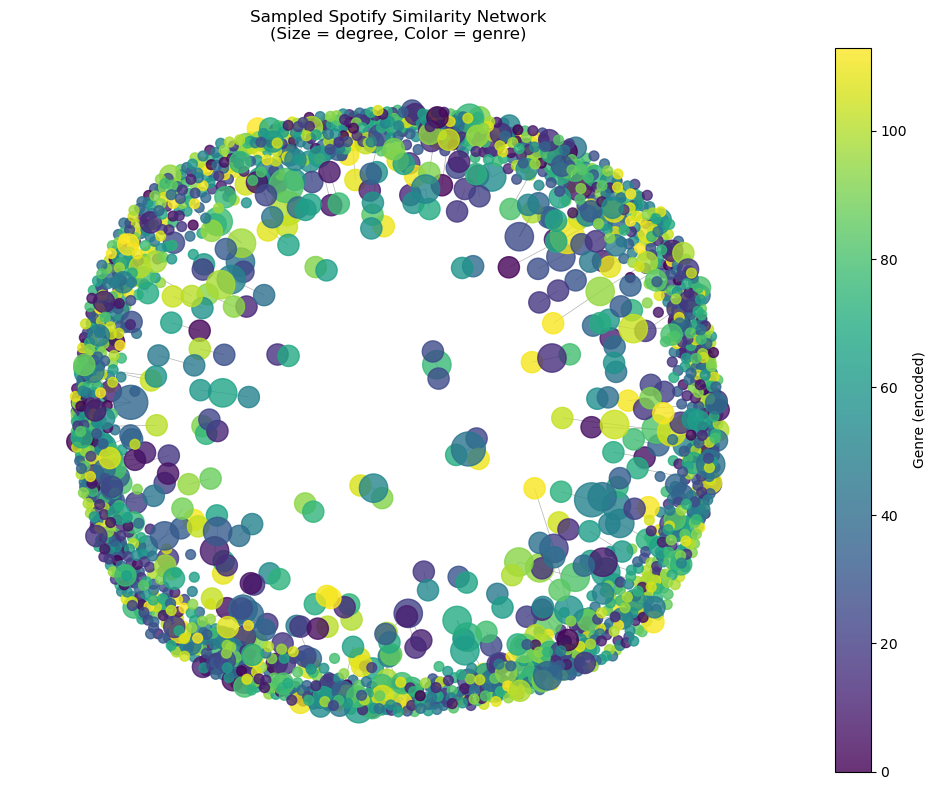

In [17]:
# Spring layout
pos = nx.spring_layout(G_sample, k=0.1, iterations=50, seed=42)

plt.figure(figsize=(10, 8))
nodes = nx.draw_networkx_nodes(
    G_sample, pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap="viridis",
    alpha=0.8
)
nx.draw_networkx_edges(G_sample, pos, alpha=0.3, width=0.5)

plt.title("Sampled Spotify Similarity Network\n(Size = degree, Color = genre)")
plt.axis("off")
cbar = plt.colorbar(nodes)
cbar.set_label(color_label)
plt.tight_layout()
plt.show()

The figure shows a sampled subgraph of the Spotify similarity network (about 2,000 nodes) laid out with a spring layout. A visualisation of a sampled subgraph with 2,000 tracks is used to inspect the local structure of the similarity network while keeping the layout computationally tractable. Nodes are sized by degree and coloured by an encoded genre label. The plot shows that node sizes are relatively similar, with no visually dominant hubs, which is consistent with the narrow degree distribution. Colours appear intermixed around the ring, suggesting that different genres are strongly interwoven in the similarity space rather than forming clearly separated clusters, although small patches of similar colours indicate the presence of locally genre-coherent groups.


# ER vs BA model comparison

A comparison of the Spotify network to: an Erdős–Rényi graph G_ER(N,M) a Barabási–Albert graph G_BA(N,m) with similar average degree using degree distributions on log–log scales.

In [18]:
# Base graph: simple giant component
G_real = G_gc_simple
N = G_real.number_of_nodes()
M = G_real.number_of_edges()
avg_k_real = 2 * M / N

print(f"Real graph: N = {N}, M = {M}, <k> ≈ {avg_k_real:.3f}")

Real graph: N = 73403, M = 424900, <k> ≈ 11.577


For model comparison, the real track similarity network is summarised by 73,403 nodes and 424,900 edges, with an average degree of approximately 11.58. These values are used to construct two synthetic reference graphs: an Erdős–Rényi random graph with the same numbers of nodes and edges, and a Barabási–Albert preferential-attachment graph with a similar average degree. Comparing degree distributions across these three networks on log–log scales makes it possible to assess whether the empirical structure is closer to a homogeneous random network or to a heterogeneous, hub-dominated scale-free topology.


In [19]:
# Erdős–Rényi G(N, M) 
rng_seed = 42
print("\n[1] Generating Erdős–Rényi G(N, M)...")
G_er = nx.gnm_random_graph(N, M, seed=rng_seed)

M_er = G_er.number_of_edges()
avg_k_er = 2 * M_er / N
print(f"ER graph: M = {M_er}, <k> ≈ {avg_k_er:.3f}")


[1] Generating Erdős–Rényi G(N, M)...
ER graph: M = 424900, <k> ≈ 11.577


An Erdős–Rényi random graph with 73,403 nodes and 424,900 edges is generated as a baseline, yielding the same average degree $\langle k \rangle \approx 11.58$ as the real network. This graph represents a purely random wiring pattern with no built-in heterogeneity or community structure and serves as a reference for assessing how far the empirical degree distribution and clustering deviate from random expectations.


In [20]:
# Barabási–Albert G_BA(N, m) 
# In BA, <k> ≈ 2m, so choose m ≈ <k_real>/2
m_ba = int(round(avg_k_real / 2))
m_ba = max(m_ba, 1)  # safety
print(f"\n[2] Generating Barabási–Albert G_BA(N={N}, m={m_ba})...")
G_ba = nx.barabasi_albert_graph(N, m_ba, seed=rng_seed)

M_ba = G_ba.number_of_edges()
avg_k_ba = 2 * M_ba / N
print(f"BA graph: M = {M_ba}, <k> ≈ {avg_k_ba:.3f}")


[2] Generating Barabási–Albert G_BA(N=73403, m=6)...
BA graph: M = 440382, <k> ≈ 11.999


A Barabási–Albert preferential-attachment graph with $N = 73{,}403$ nodes and attachment parameter $m = 6$ is generated, producing approximately $M = 440{,}382$ edges and an average degree $\langle k \rangle \approx 12$. This model provides a canonical example of a heterogeneous, hub-dominated network with a heavy-tailed degree distribution and is used as a contrasting baseline to evaluate whether the empirical network exhibits scale-free behaviour.


In [21]:
# Degree distributions 
deg_real = np.array([d for _, d in G_real.degree()])
deg_er   = np.array([d for _, d in G_er.degree()])
deg_ba   = np.array([d for _, d in G_ba.degree()])

print("\nDegree ranges:")
print(f"  Real: min={deg_real.min()}, max={deg_real.max()}")
print(f"  ER  : min={deg_er.min()},   max={deg_er.max()}")
print(f"  BA  : min={deg_ba.min()},   max={deg_ba.max()}")

# Helper to get (k, count) arrays
def degree_hist(deg_array):
    counts = np.bincount(deg_array)
    k_vals = np.arange(len(counts))
    mask = counts > 0
    return k_vals[mask], counts[mask]

k_real, c_real = degree_hist(deg_real)
k_er,   c_er   = degree_hist(deg_er)
k_ba,   c_ba   = degree_hist(deg_ba)



Degree ranges:
  Real: min=9, max=23
  ER  : min=1,   max=28
  BA  : min=6,   max=1045


The real network has degrees confined to a narrow range from 9 to 23, whereas the Erdős–Rényi baseline spans a slightly wider interval from 1 to 28, and the Barabási–Albert graph ranges from 6 up to 1,045. The extremely wide range in the Barabási–Albert model reflects the presence of very high-degree hubs, characteristic of a heavy-tailed, scale-free topology. In contrast, the empirical network shows no such extreme nodes, reinforcing the view that its degree distribution is relatively homogeneous and not hub dominated.


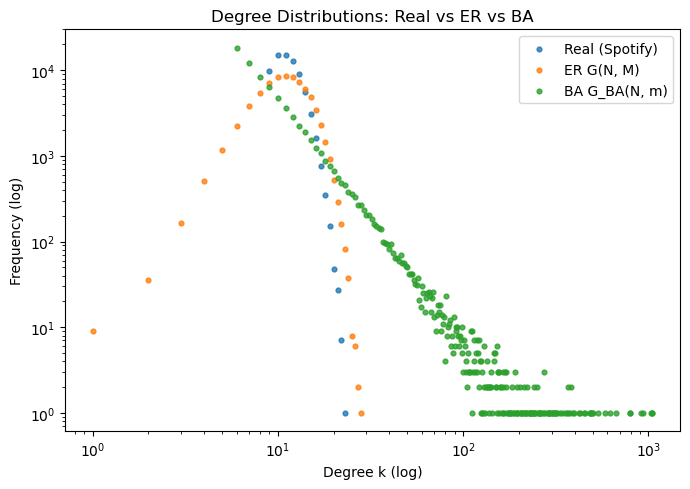

In [22]:
# Plot all three on log–log
plt.figure(figsize=(7, 5))

plt.scatter(k_real, c_real, s=12, label="Real (Spotify)", alpha=0.8)
plt.scatter(k_er,   c_er,   s=12, label="ER G(N, M)",    alpha=0.8)
plt.scatter(k_ba,   c_ba,   s=12, label="BA G_BA(N, m)", alpha=0.8)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree k (log)")
plt.ylabel("Frequency (log)")
plt.title("Degree Distributions: Real vs ER vs BA")
plt.legend()
plt.tight_layout()
plt.show()

The log–log comparison of degree distributions for the real network, the Erdős–Rényi baseline, and the Barabási–Albert model shows clearly different behaviours. The real network and the Erdős–Rényi graph both concentrate their mass in a narrow range of degrees around 10–15 and decay rapidly outside this interval, indicating relatively homogeneous connectivity. By contrast, the Barabási–Albert distribution extends smoothly over several orders of magnitude, with a long heavy tail reaching very high degrees. This visual contrast confirms that the empirical network does not exhibit the broad, scale-free degree heterogeneity characteristic of preferential-attachment models and is structurally much closer to a moderately noisy random or near-regular graph.


# Assortativity, hubs, and mixing patterns

In [23]:
G_mix = G_gc_simple

# Degree assortativity: do high-degree nodes connect to high-degree nodes?
deg_assort = nx.degree_assortativity_coefficient(G_mix)
print("\n[1] Degree assortativity:")
print(f"  r_degree = {deg_assort:.4f}")


[1] Degree assortativity:
  r_degree = 0.1037


The degree assortativity coefficient of the track similarity network is $r_{\text{degree}} = 0.1037$, indicating a weak but positive correlation between the degrees of adjacent nodes. In assortative networks with $r_{\text{degree}} > 0$, nodes with above-average degree tend to connect slightly more often to other above-degree nodes, while low-degree nodes connect more often to other low-degree nodes. The small positive value observed here suggests a mild preference for similar-degree tracks to link to each other, but the effect is not strong enough to create a sharply stratified core–periphery structure.


In [24]:
# Attribute assortativity by genre 
sample_node, sample_data = next(iter(G_mix.nodes(data=True)))
has_genre = "genre" in sample_data

if has_genre:
    try:
        genre_assort = nx.attribute_assortativity_coefficient(G_mix, "genre")
        print("\n[2] Genre assortativity:")
        print(f"  r_genre = {genre_assort:.4f}")
    except Exception as e:
        print("\n[2] Genre assortativity: could not compute:", e)
        genre_assort = None
else:
    print("\n[2] Genre assortativity: 'genre' attribute not found.")
    genre_assort = None


[2] Genre assortativity:
  r_genre = 0.0862


The genre assortativity coefficient is $r_{\text{genre}} = 0.0862$, measuring the tendency of tracks to connect to others with the same genre label. This small positive value indicates that edges between tracks of the same genre occur somewhat more frequently than would be expected by chance, but the effect is modest. The network therefore shows only weak genre homophily: genres influence the wiring pattern, yet a large fraction of similarity links still connect tracks across different genres.


In [25]:
# Hubs: top-degree nodes and how much they dominate
deg = dict(G_mix.degree())
deg_vals = np.array(list(deg.values()))
sorted_deg = sorted(deg.items(), key=lambda x: x[1], reverse=True)

top_k = 10
top_deg_nodes = sorted_deg[:top_k]
total_degree_sum = deg_vals.sum()
top_deg_sum = sum(d for _, d in top_deg_nodes)
share_edges_top = top_deg_sum / total_degree_sum

print("\n[3] Hubs and dominance:")
print(f"  Max degree: {deg_vals.max()}")
print(f"  Top {top_k} nodes average degree: {top_deg_sum / top_k:.2f}")
print(f"  Top {top_k} nodes share of total degree: {share_edges_top*100:.2f}%")


[3] Hubs and dominance:
  Max degree: 23
  Top 10 nodes average degree: 21.90
  Top 10 nodes share of total degree: 0.03%


The maximum degree in the network is 23, and the top 10 nodes have an average degree of 21.90, only slightly above the global mean. Together, these 10 highest-degree nodes account for just 0.03% of the total degree in the graph, indicating that connectivity is not concentrated in a small elite set of hubs. This pattern confirms that the network lacks dominant hub nodes and instead exhibits a relatively flat degree hierarchy.


In [26]:
# small table of top-degree nodes with genre
rows = []
for n, d in top_deg_nodes:
    rows.append({
        "node": n,
        "track_id": G_mix.nodes[n].get("track_id", n),
        "genre": G_mix.nodes[n].get("genre", "Unknown"),
        "degree": d,
    })

df_top_deg = pd.DataFrame(rows)
print("\nTop-degree nodes:")
display(df_top_deg)


Top-degree nodes:


,node,track_id,genre,degree
0,39406,1uekuY2LCOUwsHhh8oPTrB,j-rock,23
1,9059,7fP6eS6gtTs0xSAE9LvyEq,sleep,22
2,21647,7ezauNJ3kAugkv9uV9Jouu,brazil,22
3,33791,4UfZMDH9o6pw6ZwGhFOahe,gospel,22
4,33888,766Y1kYTYrEmHSTvouyHCj,club,22
5,39104,6gEttabPLI7cC61rCysc1O,sleep,22
6,52050,3t6tJx92OVwqK8KWmpM6Q6,comedy,22
7,70742,6qBpthIknZtYitTrJPdho2,hardcore,22
8,2269,7MF7QAodbGzNYav5ZfIhAY,disco,21
9,8055,6aXdJ9fD7KLRIQu3TN7LoE,sleep,21


In [27]:
# Path to the dataset
DATASET_CSV_PATH = "dataset.csv"  

# Load: track_id and track_name
meta = pd.read_csv(DATASET_CSV_PATH)
meta = meta[["track_id", "track_name"]].drop_duplicates()

print("Metadata rows:", len(meta))
display(meta.head())

# Merge track_name into the top-degree table 
df_top_deg_named = df_top_deg.merge(meta, on="track_id", how="left")

print("Top-degree nodes with names:")
display(df_top_deg_named[["track_name", "track_id", "genre", "degree"]])

Metadata rows: 89741


,track_id,track_name
0,5SuOikwiRyPMVoIQDJUgSV,Comedy
1,4qPNDBW1i3p13qLCt0Ki3A,Ghost - Acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,To Begin Again
3,6lfxq3CG4xtTiEg7opyCyx,Can't Help Falling In Love
4,5vjLSffimiIP26QG5WcN2K,Hold On


Top-degree nodes with names:


,track_name,track_id,genre,degree
0,敏感少女,1uekuY2LCOUwsHhh8oPTrB,j-rock,23
1,Arp Of Life,7fP6eS6gtTs0xSAE9LvyEq,sleep,22
2,Eu Te Levantarei (Ao Vivo),7ezauNJ3kAugkv9uV9Jouu,brazil,22
3,Firme nas Promessas,4UfZMDH9o6pw6ZwGhFOahe,gospel,22
4,Grand Design,766Y1kYTYrEmHSTvouyHCj,club,22
5,Wellen umspülen deine Sinne,6gEttabPLI7cC61rCysc1O,sleep,22
6,Travel,3t6tJx92OVwqK8KWmpM6Q6,comedy,22
7,Court of Justice,6qBpthIknZtYitTrJPdho2,hardcore,22
8,Midnight Train to Georgia,7MF7QAodbGzNYav5ZfIhAY,disco,21
9,Dream Of Flight,6aXdJ9fD7KLRIQu3TN7LoE,sleep,21


Inspection of the top-degree nodes shows that the highest-degree tracks span a wide range of genres, including j-rock, sleep, brazil, gospel, club, comedy, hardcore, and disco. No single genre dominates this list, and the hub candidates are stylistically diverse rather than belonging to a single tightly knit cluster. This diversity reinforces the conclusion that the network does not revolve around a small, genre-specific hub region but instead distributes high connectivity across multiple musical styles.


# Compute centralities + build DataFrame


In [28]:

G_cent = G_gc_simple
print(f"Graph for centrality: {G_cent.number_of_nodes()} nodes, {G_cent.number_of_edges()} edges")

# Degree & strength
deg = dict(G_cent.degree())
strength = dict(G_cent.degree(weight="weight"))

deg_vals = np.array(list(deg.values()))
str_vals = np.array(list(strength.values()))

print("\n[1] Degree / strength summary")
print(f"  Degree   min={deg_vals.min()}, max={deg_vals.max()}, mean={deg_vals.mean():.2f}")
print(f"  Strength min={str_vals.min():.3f}, max={str_vals.max():.3f}, mean={str_vals.mean():.3f}")

Graph for centrality: 73403 nodes, 424900 edges

[1] Degree / strength summary
  Degree   min=9, max=23, mean=11.58
  Strength min=2.251, max=17.963, mean=8.558


For the centrality analysis, the graph comprises 73,403 nodes and 424,900 edges. Degrees range from 9 to 23, with a mean of 11.58, confirming again that each track connects to a similar number of neighbours. The corresponding node strengths (sum of edge weights) range from 2.251 to 17.963, with a mean of 8.558, indicating that while the number of neighbours is fairly homogeneous, the total similarity to those neighbours varies more substantially. This suggests that some tracks are not necessarily more connected, but are on average more strongly similar to their neighbours than others.


In [29]:
# Centrality measures
print("\n[2] Computing degree centrality...")
deg_centrality = nx.degree_centrality(G_cent)

print("    Computing approximate betweenness centrality (k=200 samples)...")
bet_centrality = nx.betweenness_centrality(G_cent, k=200, normalized=True, seed=42)

print("    Computing eigenvector centrality (weighted)...")
eig_centrality = nx.eigenvector_centrality(G_cent, max_iter=500, tol=1e-6, weight="weight")

print("Centralities computed.")


[2] Computing degree centrality...
    Computing approximate betweenness centrality (k=200 samples)...
    Computing eigenvector centrality (weighted)...
Centralities computed.


In [30]:
# Build DataFrame with centralities
rows = []
for n in G_cent.nodes():
    attrs = G_cent.nodes[n]
    rows.append({
        "node": n,
        "track_id": attrs.get("track_id", n),
        "genre": attrs.get("genre", "Unknown"),
        "degree": deg[n],
        "strength": strength[n],
        "deg_centrality": deg_centrality[n],
        "betweenness": bet_centrality[n],
        "eigenvector": eig_centrality[n],
    })

df_cent = pd.DataFrame(rows)

In [31]:
# Merge track_name from the dataset
df_cent_named = df_cent.merge(meta[["track_id", "track_name"]].drop_duplicates(),
                              on="track_id", how="left")

print("\nCentrality DataFrame shape:", df_cent_named.shape)
df_cent_named.head()


Centrality DataFrame shape: (73403, 9)


,node,track_id,genre,degree,strength,deg_centrality,betweenness,eigenvector,track_name
0,0,3nqQXoyQOWXiESFLlDF1hG,pop,10,7.713414,0.000136,0.000144,7.342928e-06,Unholy (feat. Kim Petras)
1,1,2tTmW7RDtMQtBk7m2rYeSw,hip-hop,10,8.366022,0.000136,0.000055,1.874260e-05,"Quevedo: Bzrp Music Sessions, Vol. 52"
2,2,5ww2BF9slyYgNOk37BlC4u,reggaeton,11,8.426365,0.000150,0.000042,7.782101e-07,La Bachata
3,3,4uUG5RXrOk84mYEfFvj3cK,pop,14,11.455290,0.000191,0.000010,2.854157e-06,I'm Good (Blue)
4,4,1IHWl5LamUGEuP4ozKQSXZ,reggae,11,7.366955,0.000150,0.001395,1.668137e-07,Tití Me Preguntó


In [32]:
# Top 10 by eigenvector centrality
top_eig = df_cent_named.sort_values("eigenvector", ascending=False).head(10)
print("\n[1] Top 10 by eigenvector centrality (globally well-connected):")
display(top_eig[["track_name", "track_id", "genre", "degree", "strength",
                 "deg_centrality", "betweenness", "eigenvector"]])


[1] Top 10 by eigenvector centrality (globally well-connected):


,track_name,track_id,genre,degree,strength,deg_centrality,betweenness,eigenvector
17222,the color of the sky - solo piano,06UlQEupfklesVD0OB2N87,piano,21,17.408510,0.000286,3.636511e-06,0.227397
39502,Calming Music for Baby in the Womb,0PFK7yF46byBkDi3q6ZbRi,sleep,17,14.399836,0.000232,1.966528e-07,0.206156
7262,Winter Morning,5eKSEgKZA7CL7mA6BDX5I2,sleep,18,15.010718,0.000245,2.490458e-07,0.203473
5779,Mirrors,4AxLkuDH6lAh4zfAqnMk1n,sleep,18,14.883063,0.000245,2.477717e-05,0.192537
8949,A Waiting,6eua7DXiCZaYulrVuPI3i7,sleep,19,15.610915,0.000259,2.022545e-05,0.189988
6470,Pause,2IrOsuqSttz8KBastkZCzy,sleep,15,12.585509,0.000204,1.021332e-07,0.171035
71061,"Gaspard de la nuit, M. 55: I. Ondine, Lent",5m7Ca5SkWEL3qPEScXcRw0,classical,14,11.776685,0.000191,9.659856e-07,0.165511
7267,Unavailable,3JvHEEbo89vp4EJw0PZMPJ,sleep,16,13.259707,0.000218,1.610400e-05,0.161719
8895,Eleven Degrees North,1ytBTJUCVq3ljXsEri2Bel,sleep,16,12.995153,0.000218,2.166536e-06,0.147061
4648,Turndown Service,56y8h73SZXnIzR0fGSQlca,sleep,12,10.084642,0.000163,4.835446e-07,0.144716


The tracks with the highest eigenvector centrality are dominated by quiet, atmospheric styles such as sleep music, solo piano, and classical pieces. These tracks typically have moderately high degree and strength, indicating many reasonably strong similarity links to other well-connected nodes. High eigenvector scores therefore place them in the dense core of the network, where they are indirectly linked to a large portion of the graph via other central neighbours. The very low betweenness values for these tracks suggest that they are not critical bridges between distant regions, but rather occupy a globally well-integrated, highly redundant neighbourhood in the similarity space.


In [33]:
# Top 10 by betweenness centrality
top_bet = df_cent_named.sort_values("betweenness", ascending=False).head(10)
print("\n[2] Top 10 by betweenness centrality (bridges between regions):")
display(top_bet[["track_name", "track_id", "genre", "degree", "strength",
                 "deg_centrality", "betweenness", "eigenvector"]])


[2] Top 10 by betweenness centrality (bridges between regions):


,track_name,track_id,genre,degree,strength,deg_centrality,betweenness,eigenvector
72751,Random City Tehran P.3 - 2016 edition,7ndmFXGKHcyvxzNlkF8UEV,iranian,10,5.419960,0.000136,0.013581,1.895615e-07
62605,In the Dungeon,2JVTTnyOZpkra28KPIcNSV,club,9,4.368196,0.000123,0.012482,1.096257e-07
46434,Sonido Del Viento - Música de Fondo para Masaj...,60iVN2c4KpoB9teVSBzmzt,world-music,9,3.259770,0.000123,0.010309,1.597583e-07
39468,BODYGUARD!,2COpCHmdoG0mhV3D3NA2tD,industrial,12,7.549692,0.000163,0.010109,1.223907e-05
33965,Slow and Subdued Brown Wave,0aSQ98crQLAOa6PYUJW9Rg,sleep,10,3.760265,0.000136,0.009552,1.431678e-05
46121,Megaman 2,3An7MrOZHfQCg789ZuqXnD,comedy,11,5.978454,0.000150,0.009020,1.278489e-07
38916,I Got Guns in My Head,4r7k7OI7sSXihQA84LpFYI,sad,13,7.290151,0.000177,0.008874,3.646187e-07
40164,Chienne de vie,0o3c5qfqOU5b3Vrlmx7TUP,french,10,5.525814,0.000136,0.008620,7.392013e-08
25733,Money Talk,0r0v060GKpseOx3zxy0d2b,dubstep,10,6.006815,0.000136,0.008585,1.271200e-07
23849,Konbini,4N1JHcYR9TskJmqj2g5uA6,piano,9,2.394509,0.000123,0.008113,2.159850e-05


Tracks with the highest betweenness centrality form a heterogeneous set spanning genres such as iranian, club, world-music, industrial, sleep, comedy, sad, french, dubstep, and piano. These nodes have only moderate degree and strength, but they achieve large betweenness scores, indicating that many shortest paths between other tracks pass through them. High betweenness combined with modest local connectivity suggests that these tracks act as bridges linking otherwise weakly connected regions of the network, facilitating interaction between distinct stylistic zones rather than forming part of the densely connected core.



# k-core / core–periphery structure

- How “deep” the network is (max core index).

- How many nodes lie in low vs high cores.

- What kind of tracks live in the innermost core (the dense backbone).

In [34]:
G_core = G_gc_simple

# Compute k-core numbers for all nodes
core_num = nx.core_number(G_core)  # dict: node -> k

k_vals = np.array(list(core_num.values()))
k_min, k_max = k_vals.min(), k_vals.max()

print("\n[1] Core index summary")
print(f"  k_min  = {k_min}")
print(f"  k_max  = {k_max}")
print(f"  mean k = {k_vals.mean():.2f}")


[1] Core index summary
  k_min  = 9
  k_max  = 9
  mean k = 9.00


The $k$-core decomposition of the track similarity network yields a single core index, with $k_{\min} = k_{\max} = 9$ and mean $k = 9$. In a $k$-core analysis, larger core indices correspond to nodes that remain after successively pruning all vertices with degree less than $k$, revealing progressively denser backbones. The fact that every node lies in the 9-core and no higher cores exist indicates that the network is structurally shallow, with no inner subset of substantially more densely connected tracks. This outcome is consistent with the narrow degree range and reinforces the picture of a relatively homogeneous connectivity pattern without a pronounced core–periphery hierarchy.


In [35]:
# Distribution of core sizes
unique_k, counts_k = np.unique(k_vals, return_counts=True)
print("\n[2] Core size distribution (k, #nodes):")
for k, c in zip(unique_k, counts_k):
    print(f"  k = {k:2d} : {c:6d} nodes")



[2] Core size distribution (k, #nodes):
  k =  9 :  73403 nodes


The core size distribution shows a single value, with $k = 9$ containing all 73,403 nodes. Thus, every track belongs to the 9-core and there are no smaller or larger cores. This uniform assignment confirms that the network lacks a layered core–periphery structure and that all nodes participate in a backbone of similar minimum connectivity.


In [36]:
# Focus on the highest core (backbone-like set)
k_star = k_max
nodes_high_core = [n for n, k in core_num.items() if k == k_star]
print(f"\n[3] Highest core:")
print(f"  k* = {k_star}")
print(f"  |C_k*| = {len(nodes_high_core)} nodes")


[3] Highest core:
  k* = 9
  |C_k*| = 73403 nodes


The highest core index is $k^* = 9$, and the corresponding core $C_{k^*}$ contains all 73,403 nodes. Since the innermost core coincides with the entire network, there is no smaller, denser subset of tracks that can be isolated by iterative degree pruning. This result reinforces the view that the graph is uniformly well connected and does not exhibit a distinct, high-density nucleus separated from a sparser periphery.


In [37]:
# Build small table of some nodes from the highest core
rows = []
for n in nodes_high_core[:20]:  # show first 20
    attrs = G_core.nodes[n]
    rows.append({
        "node": n,
        "track_id": attrs.get("track_id", n),
        "genre": attrs.get("genre", "Unknown"),
        "degree": G_core.degree(n)
    })

df_high_core = pd.DataFrame(rows)

In [38]:
# Merge track names 
if "meta" in globals():
    df_high_core_named = df_high_core.merge(
        meta[["track_id", "track_name"]].drop_duplicates(),
        on="track_id", how="left"
    )
    print("\nExample nodes from highest k-core (with names):")
    display(df_high_core_named[["track_name", "track_id", "genre", "degree"]])
else:
    print("\nExample nodes from highest k-core:")
    display(df_high_core)


Example nodes from highest k-core (with names):


,track_name,track_id,genre,degree
0,Unholy (feat. Kim Petras),3nqQXoyQOWXiESFLlDF1hG,pop,10
1,"Quevedo: Bzrp Music Sessions, Vol. 52",2tTmW7RDtMQtBk7m2rYeSw,hip-hop,10
2,La Bachata,5ww2BF9slyYgNOk37BlC4u,reggaeton,11
3,I'm Good (Blue),4uUG5RXrOk84mYEfFvj3cK,pop,14
4,Tití Me Preguntó,1IHWl5LamUGEuP4ozKQSXZ,reggae,11
5,Me Porto Bonito,6Sq7ltF9Qa7SNFBsV5Cogx,latino,12
6,Under The Influence,5IgjP7X4th6nMNDh4akUHb,pop,12
7,Efecto,5Eax0qFko2dh7Rl2lYs3bx,latin,13
8,I Ain't Worried,4h9wh7iOZ0GGn8QVp4RAOB,pop,11
9,Ojitos Lindos,3k3NWokhRRkEPhCzPmV8TW,latino,10


A sample of tracks from the highest $k$-core ($k = 9$) consists largely of recent, mainstream songs spanning pop, hip-hop, reggaeton, Latin, dance, chill, indie, and related genres. These tracks have moderately high degrees (around 9–16), indicating that each is directly similar to a substantial set of neighbours. The prominence of widely popular, cross-genre songs in this core suggests that the innermost backbone of the network is formed by broadly accessible tracks that connect many stylistic neighbourhoods, rather than by highly specialised or niche material.


# Backbone Analysis

Number of edges with weights: 424900
Weight range: min=0.2334, max=1.0000
Mean weight: 0.7392
50th percentile: 0.7525
75th percentile: 0.7978
90th percentile: 0.8307
95th percentile: 0.8504
99th percentile: 0.8898


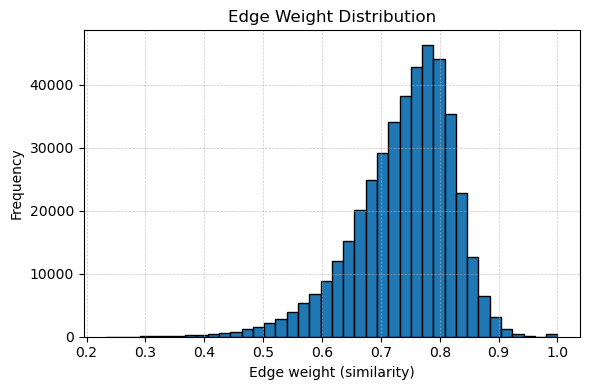

In [39]:
# WEIGHT-BASED BACKBONE
G_w = G_gc_simple 

# Collect all edge weights
weights = [data.get("weight", 1.0) for _, _, data in G_w.edges(data=True)]
weights = np.array(weights)

print(f"Number of edges with weights: {len(weights)}")
print(f"Weight range: min={weights.min():.4f}, max={weights.max():.4f}")
print(f"Mean weight: {weights.mean():.4f}")

# Some useful percentiles
for q in [50, 75, 90, 95, 99]:
    print(f"{q}th percentile: {np.percentile(weights, q):.4f}")

# Quick histogram
plt.figure(figsize=(6,4))
plt.hist(weights, bins=40, edgecolor="black")
plt.xlabel("Edge weight (similarity)")
plt.ylabel("Frequency")
plt.title("Edge Weight Distribution")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
plt.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()


Edge weights, interpreted as pairwise similarity scores, are available for all 424,900 edges and range from 0.2334 to 1.0000, with a mean of 0.7392. The histogram shows a unimodal distribution concentrated between approximately 0.6 and 0.85, and the percentile values indicate that 50% of edges have weight at least 0.7525, 75% at least 0.7978, and 95% at least 0.8504. Thus, most connected track pairs are already fairly similar, while only a small fraction of edges reach very high similarity values close to 1. This structure motivates backbone extractions based on high-weight thresholds, which isolate the strongest ties from an already dense field of moderately strong similarities.


In [40]:
# WEIGHT-BASED BACKBONE
G_full = G_gc_simple

# Choose threshold around 90th percentile (~0.8498 from previous block)
BACKBONE_THRESH = 0.85
print(f"Using backbone threshold: weight >= {BACKBONE_THRESH:.3f}")

N_full = G_full.number_of_nodes()
M_full = G_full.number_of_edges()
avgk_full = 2 * M_full / N_full

print(f"\nFull graph:")
print(f"  Nodes N_full = {N_full}")
print(f"  Edges M_full = {M_full}")
print(f"  <k>_full     = {avgk_full:.2f}")

# Build backbone by keeping only strong edges
G_backbone = nx.Graph()
G_backbone.add_nodes_from(G_full.nodes(data=True))

kept_edges = 0
for u, v, data in G_full.edges(data=True):
    w = data.get("weight", 1.0)
    if w >= BACKBONE_THRESH:
        G_backbone.add_edge(u, v, **data)
        kept_edges += 1

print(f"\nBackbone edges kept (before cleaning isolates): {kept_edges}")

# Remove isolated nodes (nodes with degree 0 in the backbone)
isolates = list(nx.isolates(G_backbone))
G_backbone.remove_nodes_from(isolates)

N_bb = G_backbone.number_of_nodes()
M_bb = G_backbone.number_of_edges()
avgk_bb = 2 * M_bb / N_bb if N_bb > 0 else 0.0

print("\nBackbone graph (after removing isolates):")
print(f"  Nodes N_bb = {N_bb}")
print(f"  Edges M_bb = {M_bb}")
print(f"  <k>_bb     = {avgk_bb:.2f}")
print(f"  Edge fraction M_bb / M_full = {M_bb / M_full:.3%}")

# Components in backbone
components_bb = list(nx.connected_components(G_backbone))
sizes_bb = sorted([len(c) for c in components_bb], reverse=True)

print("\nBackbone connectivity:")
print(f"  #components = {len(components_bb)}")
print(f"  Largest component size = {sizes_bb[0] if sizes_bb else 0}")

# Keep backbone graph for community detection / visualisation
G_backbone_085 = G_backbone

Using backbone threshold: weight >= 0.850

Full graph:
  Nodes N_full = 73403
  Edges M_full = 424900
  <k>_full     = 11.58

Backbone edges kept (before cleaning isolates): 21552

Backbone graph (after removing isolates):
  Nodes N_bb = 23670
  Edges M_bb = 21552
  <k>_bb     = 1.82
  Edge fraction M_bb / M_full = 5.072%

Backbone connectivity:
  #components = 6403
  Largest component size = 3422


Applying a hard threshold of weight $\geq 0.850$ produces a backbone that retains only the strongest 5.07% of edges (21,552 out of 424,900). After removing isolates, the backbone contains 23,670 nodes with an average degree $\langle k \rangle_{\text{bb}} = 1.82$, forming 6,403 connected components, the largest of which has 3,422 nodes. This strong-filter backbone therefore fragments the network into many small clusters and a few medium-sized components, indicating that very high similarity relations are relatively rare and tend to organise tracks into tight local islands rather than a single, globally cohesive structure.


# Backbone Visualisation

In [41]:
G_bb = G_backbone_085
# Extract largest connected component of backbone
components_bb = list(nx.connected_components(G_bb))
giant_bb_nodes = max(components_bb, key=len)
G_bb_giant = G_bb.subgraph(giant_bb_nodes).copy()

print(f"Largest backbone component: {G_bb_giant.number_of_nodes()} nodes, "
      f"{G_bb_giant.number_of_edges()} edges")

Largest backbone component: 3422 nodes, 5456 edges


In [42]:
# Node size = degree in backbone giant component
deg_bb = dict(G_bb_giant.degree())
deg_vals_bb = np.array(list(deg_bb.values()))
min_deg_bb, max_deg_bb = deg_vals_bb.min(), deg_vals_bb.max()

min_size, max_size = 40, 500
if max_deg_bb == min_deg_bb:
    node_sizes = [300] * len(deg_bb)
else:
    node_sizes = [
        min_size + (max_size - min_size) * (d - min_deg_bb) / (max_deg_bb - min_deg_bb)
        for d in deg_bb.values()
    ]

In [43]:
# Node colour = genre
sample_node, sample_data = next(iter(G_bb_giant.nodes(data=True)))
has_genre = "genre" in sample_data

if has_genre:
    genres = [G_bb_giant.nodes[n].get("genre", "Unknown") for n in G_bb_giant.nodes()]
    unique_genres = {g: i for i, g in enumerate(sorted(set(genres)))}
    node_colors = [unique_genres[g] for g in genres]
    color_label = "Genre (encoded as integers)"
    print("Colouring nodes by 'genre'.")
else:
    node_colors = list(deg_bb.values())
    color_label = "Degree"
    print("No 'genre' attribute found, colouring by degree.")

Colouring nodes by 'genre'.


Computing spring layout on backbone giant component...


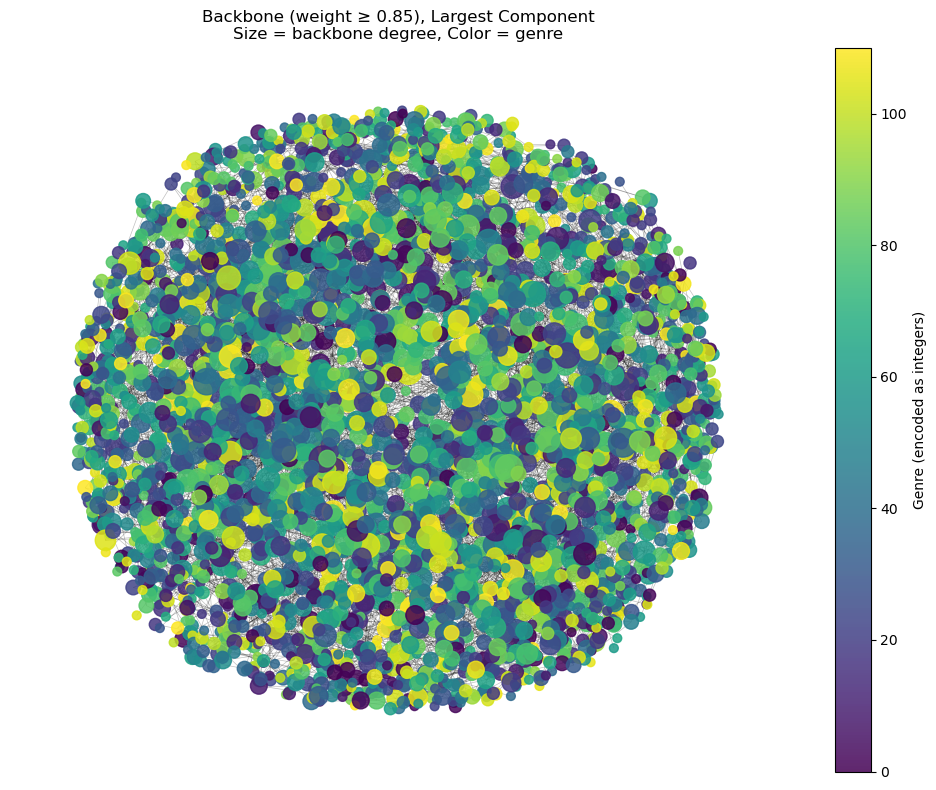

In [44]:
# Spring layout on backbone giant component
print("Computing spring layout on backbone giant component...")
pos = nx.spring_layout(G_bb_giant, k=0.2, iterations=60, seed=42)

plt.figure(figsize=(10, 8))
nodes = nx.draw_networkx_nodes(
    G_bb_giant,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap="viridis",
    alpha=0.85,
)
nx.draw_networkx_edges(G_bb_giant, pos, alpha=0.25, width=0.5)

plt.title("Backbone (weight ≥ 0.85), Largest Component\n"
          "Size = backbone degree, Color = genre")
plt.axis("off")
cbar = plt.colorbar(nodes)
cbar.set_label(color_label)
plt.tight_layout()
plt.show()

The largest component of the high-similarity backbone (weight $\geq 0.850$) contains 3,422 nodes and 5,456 edges. In the visualisation, node size reflects degree within this backbone and colour encodes genre. Most nodes have relatively small backbone degree, with only a few slightly larger nodes, indicating that even among the strongest ties the structure is not dominated by star-like hubs. Genre colours are heavily intermixed rather than forming sharply separated blocks, suggesting that very strong similarity relations frequently connect tracks across different genres, although small local patches of similar colours indicate pockets of genre-coherent clusters within this dense core.


### DISPARITY FILTER BACKBONE (WEIGHT-BASED)

In [45]:
Gw = G_gc_simple   # simple, undirected, weighted giant component

# --- Disparity filter (Serrano et al. 2009) ---
def disparity_backbone(Gw, alpha=0.20, mode="or"):
    """
    Undirected disparity filter backbone.
    Gw: weighted undirected graph with edge attribute 'weight'.
    alpha: significance level.
    mode: 'or' keeps edge if significant at either endpoint; 'and' requires both.
    """
    assert not Gw.is_directed()
    B = nx.Graph()
    B.add_nodes_from(Gw.nodes(data=True))

    # Degree and node strength
    deg = dict(Gw.degree())
    strength = {n: 0.0 for n in Gw.nodes()}
    for u, v, d in Gw.edges(data=True):
        w = float(d.get("weight", 1.0))
        strength[u] += w
        strength[v] += w

    def significant(p, k):
        if k <= 1:
            return True
        # Tail probability under random allocation of weights
        return (1.0 - p) ** (k - 1) < alpha

    for u, v, d in Gw.edges(data=True):
        w = float(d.get("weight", 1.0))
        pu = w / strength[u] if strength[u] > 0 else 0.0
        pv = w / strength[v] if strength[v] > 0 else 0.0
        keep_u = significant(pu, deg[u])
        keep_v = significant(pv, deg[v])
        keep = (keep_u or keep_v) if mode == "or" else (keep_u and keep_v)
        if keep:
            B.add_edge(u, v, **d)

    return B

alpha_disp = 0.35
B_disp = disparity_backbone(Gw, alpha=alpha_disp, mode="or")

edges_full = Gw.number_of_edges()
edges_disp = B_disp.number_of_edges()
frac_kept_disp = edges_disp / edges_full
components_disp = nx.number_connected_components(B_disp)

print(f"[Disp] Backbone edges: {edges_disp} / {edges_full} ({frac_kept_disp:.1%} kept)")
print(f"[Disp] Number of connected components: {components_disp}")

# Keep for later blocks
B_disp_backbone = B_disp

[Disp] Backbone edges: 30967 / 424900 (7.3% kept)
[Disp] Number of connected components: 45475


[Disp] Backbone GCC for plotting: 931 nodes, 1212 edges
Computing ForceAtlas2 layout (this can take a bit)...


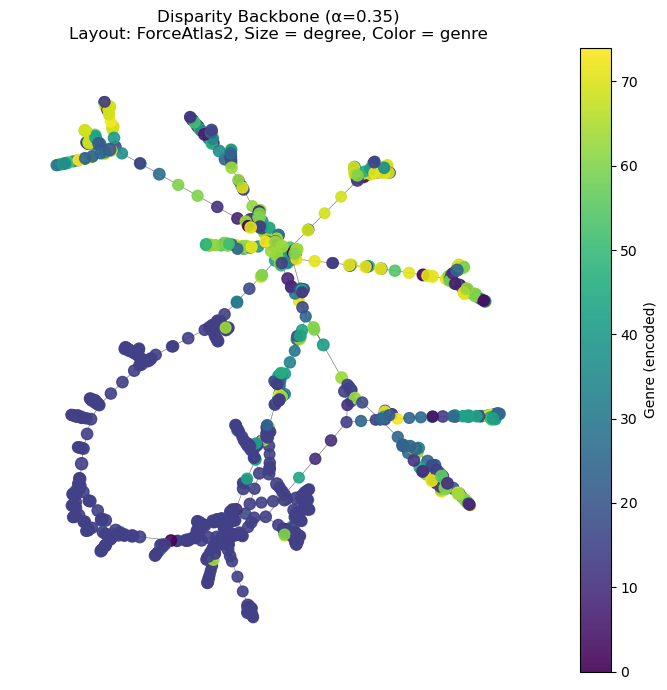

In [46]:
H = B_disp_backbone.copy()

# Drop isolates
isolates = list(nx.isolates(H))
H.remove_nodes_from(isolates)

# Largest component for plotting
if H.number_of_nodes() > 0:
    gcc_nodes_disp = max(nx.connected_components(H), key=len)
    H_gcc = H.subgraph(gcc_nodes_disp).copy()
else:
    H_gcc = H

print(f"[Disp] Backbone GCC for plotting: {H_gcc.number_of_nodes()} nodes, "
      f"{H_gcc.number_of_edges()} edges")

# Node sizes based on original degree in G_gc_simple
degrees_full = dict(G_gc_simple.degree())
sizes_disp = 40 + 2.0 * np.array([degrees_full[n] for n in H_gcc.nodes()])

# ForceAtlas2 layout
forceatlas2 = ForceAtlas2(
    outboundAttractionDistribution=False,
    linLogMode=False,
    adjustSizes=False,
    edgeWeightInfluence=1.0,
    jitterTolerance=1.0,
    barnesHutOptimize=True,
    barnesHutTheta=1.2,
    scalingRatio=2.0,
    strongGravityMode=False,
    gravity=1.0,
    verbose=False,
)

print("Computing ForceAtlas2 layout (this can take a bit)...")
pos_disp = forceatlas2.forceatlas2_networkx_layout(
    H_gcc,
    pos=None,
    iterations=1000
)

# Colour by genre 
sample_node, sample_data = next(iter(H_gcc.nodes(data=True)))
has_genre = "genre" in sample_data

if has_genre:
    genres = [H_gcc.nodes[n].get("genre", "Unknown") for n in H_gcc.nodes()]
    unique_genres = {g: i for i, g in enumerate(sorted(set(genres)))}
    node_colors = [unique_genres[g] for g in genres]
    color_label = "Genre (encoded)"
else:
    node_colors = [degrees_full[n] for n in H_gcc.nodes()]
    color_label = "Degree"

fig, ax = plt.subplots(figsize=(7, 7))
nx.draw_networkx_edges(H_gcc, pos_disp, width=0.5, alpha=0.5, ax=ax)
nodes = nx.draw_networkx_nodes(
    H_gcc,
    pos_disp,
    node_size=sizes_disp,
    node_color=node_colors,
    cmap="viridis",
    alpha=0.9,
    ax=ax,
)

ax.set_title(
    f"Disparity Backbone (α={alpha_disp})\n"
    "Layout: ForceAtlas2, Size = degree, Color = genre",
    fontsize=12
)
ax.set_axis_off()
cbar = plt.colorbar(nodes, ax=ax)
cbar.set_label(color_label)
plt.tight_layout()
plt.show()


In addition to a simple hard-threshold backbone, a disparity filter is applied to the weighted network in order to retain edges that are statistically significant relative to each node’s local weight distribution. Whereas a global threshold keeps all edges with weight above a fixed cutoff (e.g. $w \geq 0.85$) and discards all others, the disparity approach tests, for each node, whether a given edge weight is unexpectedly large given the node’s degree and total strength. This procedure can preserve moderately weighted edges that are locally dominant for low-strength nodes, while discarding some high-weight edges that are not exceptional for very strong nodes. Neither method is universally superior: the hard threshold is simpler and highlights only the very strongest similarities, while the disparity filter produces a more statistically grounded, multi-scale backbone.

For the disparity backbone with significance level $\alpha = 0.35$, 30,967 edges are retained out of 424,900 in the full graph, corresponding to 7.3% of all edges, and the resulting network splits into 45,475 connected components. After removing isolates, the giant component used for visualisation contains 931 nodes and 1,212 edges. In the ForceAtlas2 layout, node size reflects original degree and colour encodes genre, revealing a sparse, tree-like skeleton formed by chains and small clusters of tracks. This structure captures the most locally significant similarity relations and exposes a thin set of pathways that connect different stylistic regions, providing a complementary view to the dense, cluster-dominated backbone obtained with the global weight threshold.


# GENRE-BASED MODULARITY ON FULL NETWORK
- detect communities on the backbone giant component

- compute modularity and community sizes

- look at genre composition of the biggest communities

In [47]:
G_full = G_gc_simple
print(f"Full graph: {G_full.number_of_nodes()} nodes, {G_full.number_of_edges()} edges")

# --- modularity helper (eq. 9.12 from Network Science) ---
def calculate_modularity(G, communities_dict):
    """
    G: undirected graph
    communities_dict: node -> community_label (string or int)
    Unweighted modularity as in Barabási, Chapter 9.
    """
    L = G.number_of_edges()
    if L == 0:
        raise ValueError("Graph has no edges")

    M = 0.0
    # group nodes by community
    comm_nodes = {}
    for node, c in communities_dict.items():
        comm_nodes.setdefault(c, set()).add(node)

    for c, nodes in comm_nodes.items():
        sub = G.subgraph(nodes)
        L_c = sub.number_of_edges()                   # internal edges
        k_c = sum(dict(G.degree(nodes)).values())     # sum of degrees
        M += (L_c / L) - (k_c / (2 * L)) ** 2

    return M

# build genre-based partition: node -> genre label 
genre_partition = {}
for n, data in G_full.nodes(data=True):
    genre_partition[n] = data.get("genre", "unknown")

Q_genre_full = calculate_modularity(G_full, genre_partition)
print(f"Genre-based modularity on full graph: Q_genre = {Q_genre_full:.4f}")


Full graph: 73403 nodes, 424900 edges
Genre-based modularity on full graph: Q_genre = 0.0853


Using the declared track genres as community labels on the full similarity network (73,403 nodes and 424,900 edges) yields a modularity of $Q_{\text{genre}} = 0.0853$. Modularity $Q$ measures how much more densely connected nodes are within the same group than would be expected under a random graph with the same degree sequence, with higher values indicating clearer community structure. The small but positive value obtained here implies that tracks sharing a genre are slightly more likely to be connected than random, but the effect is weak. Consequently, the global connectivity pattern is only loosely aligned with the official genre taxonomy, suggesting that many similarity edges link tracks across different genres.


### LOUVAIN COMMUNITIES ON FULL NETWORK

In [48]:
G_full = G_gc_simple
print(f"Full graph: {G_full.number_of_nodes()} nodes, {G_full.number_of_edges()} edges")

# Reuse calculate_modularity from previous cell

print("\n[1] Running Louvain community detection (unweighted)...")
louvain_comms = nx.community.louvain_communities(G_full, seed=42)
num_comms = len(louvain_comms)
print(f"  Detected {num_comms} communities.")

# Build node -> community mapping
louvain_map = {}
for i, comm in enumerate(louvain_comms):
    for node in comm:
        louvain_map[node] = i

# Compute modularity for Louvain partition using the same helper
Q_louvain_full = calculate_modularity(G_full, louvain_map)
print(f"\n[2] Louvain modularity on full graph: Q_louvain = {Q_louvain_full:.4f}")

# Community size summary
sizes = [(i, len(c)) for i, c in enumerate(louvain_comms)]
sizes_sorted = sorted(sizes, key=lambda x: x[1], reverse=True)

print("\n[3] Largest communities (id, size):")
for cid, size in sizes_sorted[:10]:
    print(f"  Community {cid}: {size} nodes")

Full graph: 73403 nodes, 424900 edges

[1] Running Louvain community detection (unweighted)...
  Detected 26 communities.

[2] Louvain modularity on full graph: Q_louvain = 0.8414

[3] Largest communities (id, size):
  Community 7: 4489 nodes
  Community 11: 4175 nodes
  Community 3: 3945 nodes
  Community 6: 3872 nodes
  Community 5: 3578 nodes
  Community 23: 3533 nodes
  Community 4: 3459 nodes
  Community 9: 3426 nodes
  Community 20: 3321 nodes
  Community 25: 3166 nodes


Applying Louvain community detection to the full similarity network (73,403 nodes, 424,900 edges) yields 26 communities with a modularity of $Q_{\text{Louvain}} = 0.8414$, indicating extremely strong community structure. The largest groups each contain between roughly 3,100 and 4,500 tracks (for example, communities 7, 11, 3, 6, and 5), showing that the network decomposes into several sizeable, densely connected modules rather than a single diffuse cluster. In combination with the much lower genre-based modularity, this result suggests that the graph has a pronounced intrinsic community organisation that is only partially captured by the official genre labels.


###  CONFUSION MATRIX – GENRES vs LOUVAIN COMMUNITIES

In [49]:
G = G_full 

# Collect all genres from node attributes
all_genres = []
for _, data in G.nodes(data=True):
    g = data.get("genre", "unknown")
    if g is None or g == "":
        g = "unknown"
    all_genres.append(g)

genre_counts = Counter(all_genres)

In [50]:
# Pick top K genres
TOP_K_GENRES = 7
top_genres = [g for g, _ in genre_counts.most_common(TOP_K_GENRES)]
print("Top genres:", top_genres)

Top genres: ['comedy', 'heavy-metal', 'malay', 'study', 'grindcore', 'bluegrass', 'black-metal']


In [51]:
# Top K communities by size
comm_sizes = [(cid, len(nodes)) for cid, nodes in enumerate(louvain_comms)]
comm_sizes.sort(key=lambda x: x[1], reverse=True)

TOP_K_COMMS = 7
top_comm_ids = [cid for cid, _ in comm_sizes[:TOP_K_COMMS]]
print("Top communities:", top_comm_ids)


Top communities: [7, 11, 3, 6, 5, 23, 4]


In [52]:
# Confusion matrix D[genre, community]
D = pd.DataFrame(0, index=top_genres, columns=top_comm_ids)

for n, data in G.nodes(data=True):
    g = data.get("genre", "unknown")
    if g is None or g == "":
        g = "unknown"
    if g not in top_genres:
        continue

    comm = louvain_map.get(n, None)
    if comm not in top_comm_ids:
        continue

    D.loc[g, comm] += 1

print("\nConfusion matrix D (Top genres × Top communities):")
print(D)


Confusion matrix D (Top genres × Top communities):
             7    11  3    6    5   23  4 
comedy       15   26  76    0    1   4   6
heavy-metal  90    0   5  211   43   1  24
malay        31  102  68   11    0  55  92
study         4    6  26    0    8  14   3
grindcore    22    0  11   20  513   1   1
bluegrass    92   92   5    7    7  58  88
black-metal  14    0   1   43  333   3   4


A confusion matrix between the seven most frequent genres (`comedy`, `heavy-metal`, `malay`, `study`, `grindcore`, `bluegrass`, `black-metal`) and the seven largest Louvain communities (IDs 7, 11, 3, 6, 5, 23, 4) shows a mixed pattern of alignment. Some genres are strongly concentrated in a single community: for example, `grindcore` and `black-metal` are heavily overrepresented in community 5, and `comedy` has most of its tracks in a single dominant community. Other genres, such as `malay`, `bluegrass`, and `heavy-metal`, are spread across several communities, with substantial counts in multiple columns of the matrix. Overall, the confusion matrix confirms that Louvain communities and declared genres are related but not equivalent: certain genres form tight clusters inside specific communities, while others are embedded in broader, mixed-genre modules.


In [53]:
# Row-wise normalised matrix
D_normalized = D.div(D.sum(axis=1).replace(0, np.nan), axis=0)
print("\nRow-normalised confusion matrix (genre-wise proportions):")
print(D_normalized)


Row-normalised confusion matrix (genre-wise proportions):
                   7         11        3         6         5         23  \
comedy       0.117188  0.203125  0.593750  0.000000  0.007812  0.031250   
heavy-metal  0.240642  0.000000  0.013369  0.564171  0.114973  0.002674   
malay        0.086351  0.284123  0.189415  0.030641  0.000000  0.153203   
study        0.065574  0.098361  0.426230  0.000000  0.131148  0.229508   
grindcore    0.038732  0.000000  0.019366  0.035211  0.903169  0.001761   
bluegrass    0.263610  0.263610  0.014327  0.020057  0.020057  0.166189   
black-metal  0.035176  0.000000  0.002513  0.108040  0.836683  0.007538   

                   4   
comedy       0.046875  
heavy-metal  0.064171  
malay        0.256267  
study        0.049180  
grindcore    0.001761  
bluegrass    0.252149  
black-metal  0.010050  


Row-normalising the confusion matrix by genre reveals how each genre is distributed across the largest Louvain communities. Several genres are highly concentrated: for example, `comedy` has roughly 60% of its tracks in a single community, `heavy-metal` places more than half of its tracks in another, and `black-metal` is even more strongly focused, with the vast majority of its tracks belonging to one community. By contrast, genres such as `malay`, `study`, and `bluegrass` are split more evenly across multiple communities, with no single module containing a clear majority of their tracks. These proportions confirm that some genres correspond closely to individual structural communities in the network, while others are more diffusely embedded in a mixed-genre community landscape.


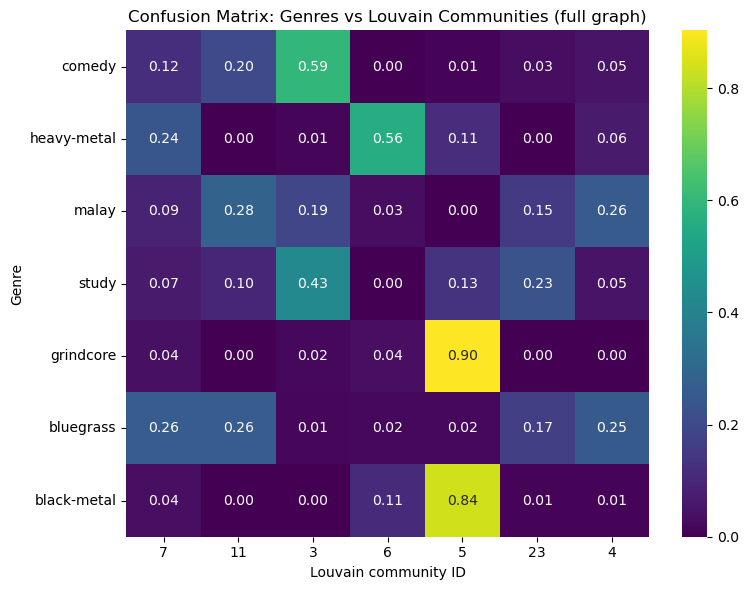

In [54]:
# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(D_normalized, annot=True, cmap="viridis", fmt=".2f")
plt.xlabel("Louvain community ID")
plt.ylabel("Genre")
plt.title("Confusion Matrix: Genres vs Louvain Communities (full graph)")
plt.tight_layout()
plt.show()

The heatmap of the row-normalised confusion matrix visualises how each of the seven selected genres is distributed across the largest Louvain communities. Several genres show a strong concentration in a single community: for example, `comedy` places about 59% of its tracks in community 3, `heavy-metal` assigns roughly 56% to community 6, `grindcore` concentrates about 90% of its tracks in community 5, and `black-metal` shows a similarly sharp focus with around 84% in community 5. In contrast, genres such as `malay`, `study`, and `bluegrass` exhibit more diffuse patterns, with substantial mass spread over multiple communities (e.g. `bluegrass` split between communities 7, 11, 23, and 4). This pattern confirms that some genres correspond closely to well-defined structural communities, whereas others are embedded across several modules, reflecting more mixed or cross-cutting similarity relationships.


### Visualisation

Visualisation subgraph: 8000 nodes, 5038 edges
Computing ForceAtlas2 layout on sampled subgraph...


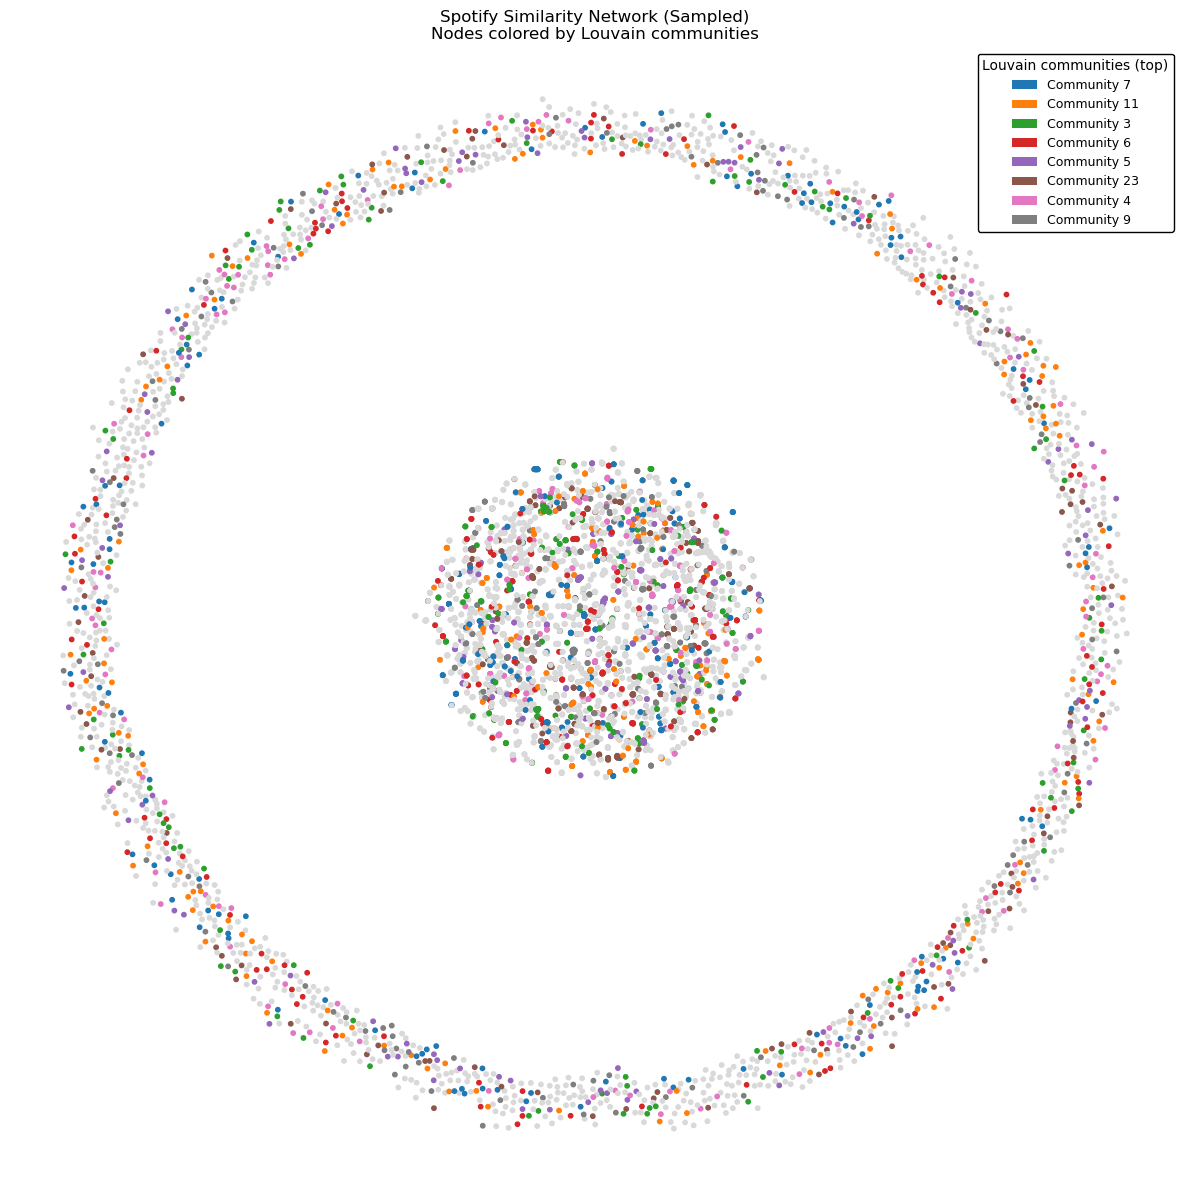

In [55]:
G = G_gc_simple  # full simple graph

# sampling for visualisation 
np.random.seed(42)
TARGET_SAMPLE_SIZE = 8000  
sample_size = min(TARGET_SAMPLE_SIZE, G.number_of_nodes())

sample_nodes = np.random.choice(list(G.nodes()), size=sample_size, replace=False)
G_vis = G.subgraph(sample_nodes).copy()

print(f"Visualisation subgraph: {G_vis.number_of_nodes()} nodes, {G_vis.number_of_edges()} edges")

# ForceAtlas2 layout on sampled graph 
forceatlas2 = ForceAtlas2(
    outboundAttractionDistribution=True,
    linLogMode=False,
    adjustSizes=False,
    edgeWeightInfluence=1.0,
    jitterTolerance=1.0,
    barnesHutOptimize=True,
    barnesHutTheta=1.2,
    scalingRatio=10.0,
    gravity=1.0,
    verbose=False,
)

print("Computing ForceAtlas2 layout on sampled subgraph...")
pos = forceatlas2.forceatlas2_networkx_layout(G_vis, pos=None, iterations=500)

# choose top communities for colouring
comm_sizes = sorted(
    ((cid, len(nodes)) for cid, nodes in enumerate(louvain_comms)),
    key=lambda x: x[1],
    reverse=True,
)
top_n = 8
top_comm_ids = [cid for cid, _ in comm_sizes[:top_n]]

palette = sns.color_palette("tab10", n_colors=len(top_comm_ids))
community_palette = {comm: palette[i] for i, comm in enumerate(top_comm_ids)}
default_color = (0.85, 0.85, 0.85)  # light grey for small communities

# Map each sampled node to a color based on its Louvain community
node_colors = [
    community_palette.get(louvain_map.get(node, -1), default_color)
    for node in G_vis.nodes()
]

plt.figure(figsize=(12, 12))
nx.draw_networkx_edges(G_vis, pos, alpha=0.03, width=0.3, edge_color="gray")
nx.draw_networkx_nodes(G_vis, pos, node_size=10, node_color=node_colors)

# Legend for top communities
legend_handles = [
    Patch(
        facecolor=community_palette[comm],
        edgecolor="none",
        label=f"Community {comm}",
    )
    for comm in top_comm_ids
]

plt.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=True,
    fancybox=True,
    framealpha=1.0,
    edgecolor="black",
    fontsize=9,
    title="Louvain communities (top)",
)

plt.title("Spotify Similarity Network (Sampled)\nNodes colored by Louvain communities")
plt.axis("off")
plt.tight_layout()
plt.show()


A ForceAtlas2 visualisation is computed on a sampled subgraph of 8,000 tracks (rather than the full 73,403) to keep the computational cost manageable and obtain a readable layout, since force-directed algorithms scale poorly with network size. The resulting embedding exhibits a dense central mass of nodes surrounded by a more diffuse outer ring, reflecting the fact that strongly interconnected nodes are pulled toward the centre of the layout, while more weakly connected or locally tree-like regions are pushed to the periphery. Nodes are coloured by Louvain community, and the mixture of colours in both core and ring indicates that communities are tightly knit but spatially interwoven, with different modules clustered together rather than forming clearly separated islands in the visual space.


# How often do songs connect to same-genre neighbours?

In [56]:

G = G_gc_simple  # full undirected, simple graph

# Get a clean genre label for every node
genres = {}
for n, data in G.nodes(data=True):
    g = data.get("genre", "unknown")
    if g is None or g == "":
        g = "unknown"
    genres[n] = g

# Edge-level: same-genre vs cross-genre
same_edges = 0
total_edges = G.number_of_edges()

for u, v in G.edges():
    if genres[u] == genres[v]:
        same_edges += 1

frac_same_edges = same_edges / total_edges
print("\n[1] Edge-level alignment:")
print(f"  Same-genre edges: {same_edges} / {total_edges} "
      f"({frac_same_edges:.3f} of all edges)")

# Node-level: for each node, fraction of neighbours with same genre
rows = []
for n in G.nodes():
    nbrs = list(G.neighbors(n))
    k = len(nbrs)
    if k == 0:
        frac_same = np.nan
    else:
        same = sum(1 for m in nbrs if genres[m] == genres[n])
        frac_same = same / k
    rows.append({"node": n, "genre": genres[n], "deg": k, "frac_same": frac_same})

df_align = pd.DataFrame(rows)

print("\n[2] Node-level alignment (all nodes):")
print(f"  Mean fraction of same-genre neighbours:   {df_align['frac_same'].mean():.3f}")
print(f"  Median fraction of same-genre neighbours: {df_align['frac_same'].median():.3f}")

# Per-genre summary
MIN_NODES_PER_GENRE = 50

genre_stats = (
    df_align
    .groupby("genre")
    .agg(
        n_nodes=("node", "count"),
        mean_deg=("deg", "mean"),
        mean_frac_same=("frac_same", "mean"),
        median_frac_same=("frac_same", "median"),
    )
    .query("n_nodes >= @MIN_NODES_PER_GENRE")
    .sort_values("mean_frac_same", ascending=False)
)

print(f"\n[3] Per-genre alignment (genres with at least {MIN_NODES_PER_GENRE} tracks):")
print("  Top 10 by mean_frac_same:")
display(genre_stats.head(10))

print("\n  Bottom 10 by mean_frac_same:")
display(genre_stats.tail(10))



[1] Edge-level alignment:
  Same-genre edges: 40337 / 424900 (0.095 of all edges)

[2] Node-level alignment (all nodes):
  Mean fraction of same-genre neighbours:   0.093
  Median fraction of same-genre neighbours: 0.000

[3] Per-genre alignment (genres with at least 50 tracks):
  Top 10 by mean_frac_same:


,n_nodes,mean_deg,mean_frac_same,median_frac_same
genre,,,,
comedy,950,11.906316,0.760807,1.000000
sleep,787,11.864041,0.501560,0.562500
study,913,11.779847,0.360489,0.357143
grindcore,907,11.762955,0.280842,0.250000
drum-and-bass,725,11.586207,0.235352,0.181818
pagode,743,11.841184,0.219800,0.142857
black-metal,869,11.614499,0.213042,0.166667
detroit-techno,836,11.807416,0.197477,0.166667
minimal-techno,710,11.894366,0.183483,0.166667



  Bottom 10 by mean_frac_same:


,n_nodes,mean_deg,mean_frac_same,median_frac_same
genre,,,,
electronic,685,11.611679,0.014702,0.0
pop,478,11.782427,0.014406,0.0
indie-pop,377,11.803714,0.014229,0.0
soul,362,11.430939,0.013938,0.0
indie,312,11.596154,0.013229,0.0
house,222,11.680180,0.012544,0.0
blues,432,11.488426,0.012502,0.0
electro,324,11.462963,0.011721,0.0
rock,216,11.629630,0.009777,0.0


Edge-level analysis shows that 40,337 out of 424,900 edges link tracks with the same genre label, so only about $9.5\%$ of all similarity links are within-genre connections. At the node level, the mean fraction of same-genre neighbours is $0.093$, while the median is $0.000$, indicating that at least half of all tracks have no neighbours sharing their genre and that genre-homophilous ties are concentrated in a minority of nodes. This pattern implies that the network is strongly cross-genre at the local scale: most tracks are primarily connected to songs from different genres, even though there is a slight global bias towards same-genre edges.

The per-genre statistics reveal substantial heterogeneity in this behaviour. Genres such as `comedy`, `sleep`, and `study` have high mean fractions of same-genre neighbours (approximately $0.76$, $0.50$, and $0.36$, respectively), with `comedy` in particular showing a median of $1.0$, meaning that a typical comedy track is surrounded almost entirely by other comedy tracks. Other niche or stylistically tight genres, including `grindcore`, `drum-and-bass`, `pagode`, `black-metal`, and several techno subgenres, also show elevated within-genre alignment. In contrast, broad umbrella genres such as `electronic`, `pop`, `indie-pop`, `soul`, `indie`, `house`, `blues`, `electro`, `rock`, and `alternative` have very low mean same-genre fractions (around $0.01$–$0.02$ with median $0.0$), indicating that tracks in these categories are embedded in highly mixed neighbourhoods. Overall, the network combines strong within-genre clustering for a subset of specialised genres with extensive cross-genre mixing for broad, mainstream categories.


### RANDOM BASELINE (GENRE SHUFFLE)

- Randomly permute genre labels across nodes several times

- Each time, recompute the fraction of same-genre edges

- Compare the observed value (≈0.121) to the random mean + std

In [57]:
G = G_gc_simple

if "genres" not in globals():
    genres = {}
    for n, data in G.nodes(data=True):
        g = data.get("genre", "unknown")
        if g is None or g == "":
            g = "unknown"
        genres[n] = g

# Observed same-genre edge fraction (for reference)
same_obs = 0
M = G.number_of_edges()
for u, v in G.edges():
    if genres[u] == genres[v]:
        same_obs += 1
frac_same_obs = same_obs / M
print(f"\nObserved fraction of same-genre edges: {frac_same_obs:.3f}")

# Prepare arrays for fast shuffling
nodes = list(G.nodes())
node_index = {n: i for i, n in enumerate(nodes)}
genre_arr = np.array([genres[n] for n in nodes])

# Edge endpoints as index arrays
src_idx = []
dst_idx = []
for u, v in G.edges():
    src_idx.append(node_index[u])
    dst_idx.append(node_index[v])
src_idx = np.array(src_idx, dtype=np.int32)
dst_idx = np.array(dst_idx, dtype=np.int32)

# Monte Carlo over shuffled labels
NUM_SHUFFLES = 20  # increase for smoother estimate

frac_same_rand = []

rng = np.random.default_rng(42)
for it in range(NUM_SHUFFLES):
    # Permute genre labels across nodes
    shuffled = genre_arr.copy()
    rng.shuffle(shuffled)
    
    # Compare genres on each edge
    same_rand = np.sum(shuffled[src_idx] == shuffled[dst_idx])
    frac = same_rand / M
    frac_same_rand.append(frac)
    print(f"  Shuffle {it+1:2d}: frac_same = {frac:.3f}")

frac_same_rand = np.array(frac_same_rand)
mean_rand = frac_same_rand.mean()
std_rand = frac_same_rand.std(ddof=1)

print("\n[Random baseline over shuffles]")
print(f"  Mean fraction of same-genre edges (random): {mean_rand:.3f}")
print(f"  Std  fraction of same-genre edges (random): {std_rand:.3f}")
print(f"\n  Observed / random mean = {frac_same_obs / mean_rand:.2f}x")
print(f"  Difference in standard deviations: "
      f"{(frac_same_obs - mean_rand) / std_rand:.2f} σ")



Observed fraction of same-genre edges: 0.095
  Shuffle  1: frac_same = 0.009
  Shuffle  2: frac_same = 0.010
  Shuffle  3: frac_same = 0.010
  Shuffle  4: frac_same = 0.010
  Shuffle  5: frac_same = 0.009
  Shuffle  6: frac_same = 0.010
  Shuffle  7: frac_same = 0.010
  Shuffle  8: frac_same = 0.010
  Shuffle  9: frac_same = 0.010
  Shuffle 10: frac_same = 0.010
  Shuffle 11: frac_same = 0.010
  Shuffle 12: frac_same = 0.010
  Shuffle 13: frac_same = 0.009
  Shuffle 14: frac_same = 0.010
  Shuffle 15: frac_same = 0.010
  Shuffle 16: frac_same = 0.009
  Shuffle 17: frac_same = 0.010
  Shuffle 18: frac_same = 0.009
  Shuffle 19: frac_same = 0.010
  Shuffle 20: frac_same = 0.010

[Random baseline over shuffles]
  Mean fraction of same-genre edges (random): 0.010
  Std  fraction of same-genre edges (random): 0.000

  Observed / random mean = 9.89x
  Difference in standard deviations: 522.50 σ


To assess whether the observed level of genre alignment could arise by chance, a random baseline is constructed by repeatedly shuffling genre labels across nodes while keeping the network structure fixed. In the real network, the fraction of same-genre edges is $0.095$. Under 20 random shuffles, the mean fraction of same-genre edges drops to approximately $0.010$ with an extremely small standard deviation, so the observed value is about $9.9$ times higher than the random expectation. Expressed in standard deviations, the difference corresponds to roughly $522\sigma$, indicating that the probability of obtaining the observed alignment under a genre-agnostic null model is effectively zero. This comparison shows that, although most edges are still cross-genre in absolute terms, the network is strongly non-random with respect to genre: tracks connect to same-genre neighbours far more often than would be expected if genres were unrelated to the similarity structure.


# Load track dataset & detect feature columns

In [ ]:
DATASET_CSV_PATH = "dataset.csv"  

df_tracks = pd.read_csv(DATASET_CSV_PATH)
print(f"Loaded track dataset: {df_tracks.shape[0]} rows, {df_tracks.shape[1]} columns\n")

print("Columns:")
print(df_tracks.columns.tolist())

# Manually set genre + track ID columns
genre_col = "track_genre"
track_id_col = "track_id"

print(f"\nUsing genre column:      '{genre_col}'")
print(f"Using track ID column:   '{track_id_col}'")

# Pick audio feature columns explicitly (Spotify-style) 
audio_feature_cols = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
]

audio_feature_cols = [c for c in audio_feature_cols if c in df_tracks.columns]

print("\nAudio feature columns to use:")
print(audio_feature_cols)

# Preview data
print("\nPreview of features + genre:")
display(df_tracks[[genre_col] + audio_feature_cols].head())

Loaded track dataset: 114000 rows, 21 columns

Columns:
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Using genre column:      'track_genre'
Using track ID column:   'track_id'

Audio feature columns to use:
['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

Preview of features + genre:


,track_genre,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,acoustic,0.676,0.4610,0.1430,0.0322,0.000001,0.3580,0.715,87.917
1,acoustic,0.420,0.1660,0.0763,0.9240,0.000006,0.1010,0.267,77.489
2,acoustic,0.438,0.3590,0.0557,0.2100,0.000000,0.1170,0.120,76.332
3,acoustic,0.266,0.0596,0.0363,0.9050,0.000071,0.1320,0.143,181.740
4,acoustic,0.618,0.4430,0.0526,0.4690,0.000000,0.0829,0.167,119.949


### PER-GENRE AVERAGE AUDIO FEATURES

In [59]:
# Drop rows with missing genre or all-missing features
df_clean = df_tracks.dropna(subset=[genre_col])
df_clean = df_clean.dropna(subset=audio_feature_cols, how="all")

print(f"After cleaning: {df_clean.shape[0]} tracks")

# Group by genre and compute mean of audio features + count
grouped = df_clean.groupby(genre_col)

df_genre_feat = grouped[audio_feature_cols].mean()
df_genre_feat["n_tracks"] = grouped.size()

# Sort by number of tracks (descending)
df_genre_feat = df_genre_feat.sort_values("n_tracks", ascending=False)

print("\nNumber of genres:", df_genre_feat.shape[0])
print("Top 10 genres by number of tracks:")
display(df_genre_feat.head(10))

# Store for later use (radar plots + similarity graph)
print("\nSaved per-genre feature matrix in df_genre_feat "
      f"with shape {df_genre_feat.shape}")

After cleaning: 114000 tracks

Number of genres: 114
Top 10 genres by number of tracks:


,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,n_tracks
track_genre,,,,,,,,,
acoustic,0.549593,0.435368,0.043247,0.566816,0.038336,0.153244,0.424023,119.010624,1000
afrobeat,0.669580,0.702812,0.086579,0.270860,0.253483,0.184596,0.698619,119.213337,1000
alt-rock,0.534493,0.754173,0.055071,0.122162,0.054097,0.210249,0.518260,124.634404,1000
alternative,0.559927,0.720030,0.070101,0.147820,0.038159,0.201376,0.495570,122.232394,1000
ambient,0.367867,0.237162,0.041562,0.776790,0.676221,0.129283,0.167498,111.113129,1000
anime,0.537451,0.674108,0.087323,0.267734,0.262971,0.197175,0.434463,123.529616,1000
black-metal,0.296411,0.874897,0.087156,0.027056,0.440847,0.241420,0.191736,128.601515,1000
bluegrass,0.534692,0.530280,0.038690,0.556588,0.136808,0.227674,0.635093,126.578805,1000
blues,0.568567,0.581878,0.063918,0.398114,0.034092,0.191830,0.604032,116.568352,1000



Saved per-genre feature matrix in df_genre_feat with shape (114, 9)


After cleaning, the track dataset contains 114,000 songs assigned to 114 distinct `track_genre` labels. For each genre, the mean values of eight core Spotify audio features (`danceability`, `energy`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`) are computed, together with a `n_tracks` column indicating how many songs contribute to the estimate. This yields a $114 \times 9$ genre-level feature matrix in which each row can be interpreted as an “audio fingerprint” of a genre. The resulting profiles already suggest clear stylistic contrasts—for instance, acoustic and ambient genres exhibit high acousticness and relatively low energy, while black-metal combines very high energy with low valence and low acousticness. These aggregated genre vectors form the basis for the subsequent radar plots and the genre–genre similarity analysis.


### radar plots for a few selected genres

Genres used in radar plot: ['acoustic', 'black-metal', 'ambient', 'anime', 'bluegrass', 'blues']


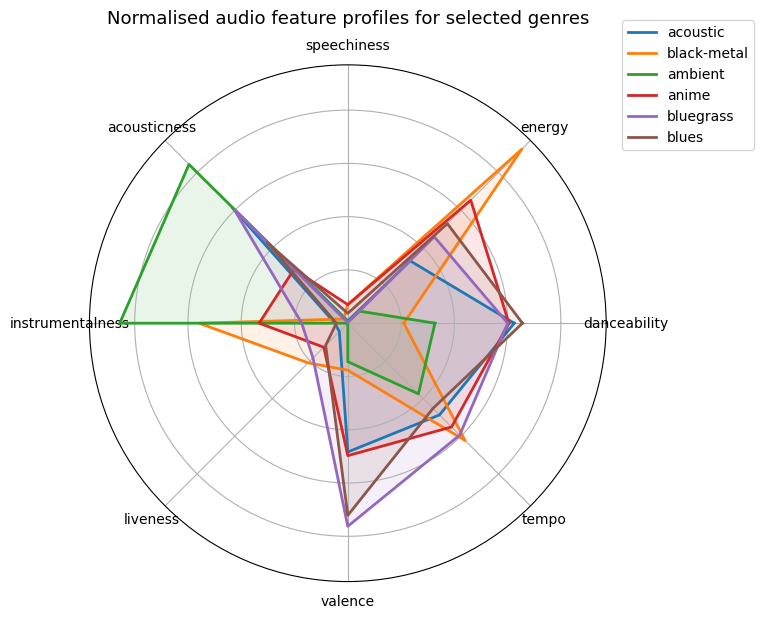

In [60]:
# Use these genres for the radar plot 
selected_genres = ["acoustic", "black-metal", "ambient", "anime", "bluegrass", "blues"]

# Keep only genres that actually exist in df_genre_feat
selected_genres = [g for g in selected_genres if g in df_genre_feat.index]
print("Genres used in radar plot:", selected_genres)

# Feature columns 
feat_cols = audio_feature_cols.copy()

# Normalise features across genres to [0,1] so scales are comparable
feat_min = df_genre_feat[feat_cols].min()
feat_max = df_genre_feat[feat_cols].max()
feat_range = (feat_max - feat_min).replace(0, 1.0)

df_norm = (df_genre_feat[feat_cols] - feat_min) / feat_range

# Radar plot setup
num_feats = len(feat_cols)
angles = np.linspace(0, 2 * np.pi, num_feats, endpoint=False)
angles = np.concatenate((angles, [angles[0]]))  # close the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})

for g in selected_genres:
    vals = df_norm.loc[g, feat_cols].values
    vals = np.concatenate((vals, [vals[0]]))  # close the loop
    ax.plot(angles, vals, label=g, linewidth=2)
    ax.fill(angles, vals, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(feat_cols, fontsize=10)
ax.set_yticklabels([])

ax.set_title("Normalised audio feature profiles for selected genres", fontsize=13, pad=30)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

Radar plots of six selected genres (`acoustic`, `black-metal`, `ambient`, `anime`, `bluegrass`, `blues`) illustrate how average audio profiles differ across the eight Spotify features. Features are first normalised to the $[0,1]$ range across genres so that each axis is comparable, and each polygon can be interpreted as the relative “shape” of a genre in feature space. The profiles show clear contrasts: `black-metal` combines very high energy with low acousticness and low valence, while `ambient` exhibits the opposite pattern with very high acousticness and instrumentalness but low energy, danceability, and speechiness. `Acoustic`, `bluegrass`, and `blues` share higher acousticness and moderate valence but differ in danceability and tempo, with `bluegrass` appearing more upbeat. `Anime` shows a more pop-like profile, with high energy and danceability and mid-range values on most other features. These distinct shapes confirm that genres occupy characteristic regions of audio-feature space rather than differing only in name.


### GENRE–GENRE COSINE SIMILARITY MATRIX

Off-diagonal similarity (z-scored) stats:
  min : -0.9513237409233336
  max : 1.0
  mean: 0.01574544659283497


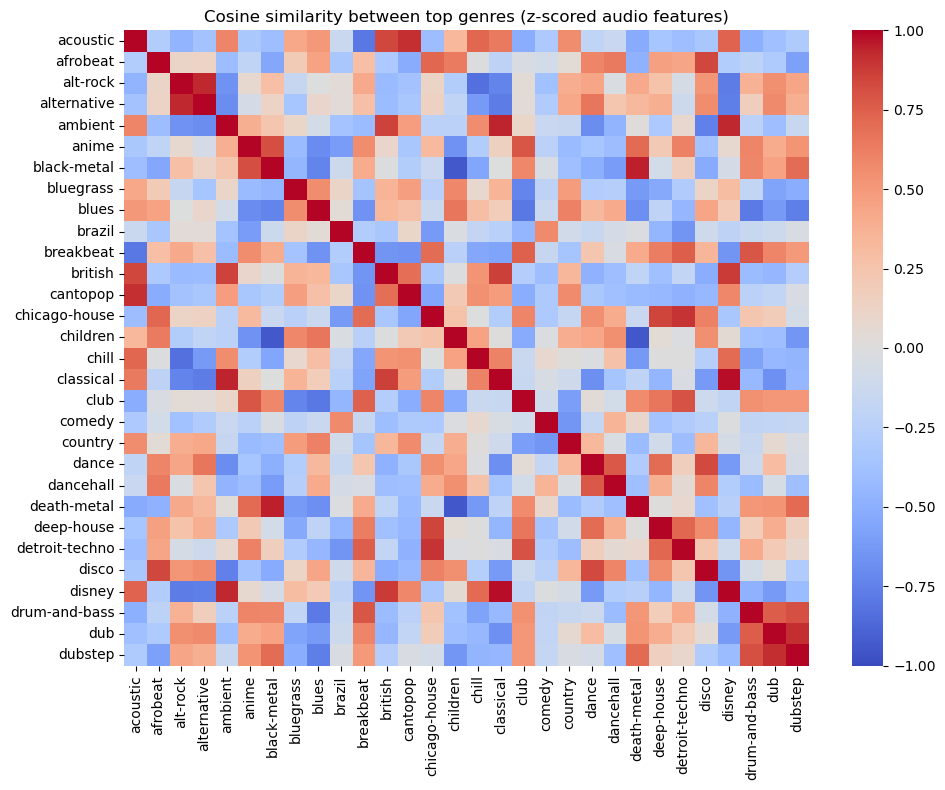

In [61]:
# Z-score features across genres
scaler = StandardScaler()
X_z = scaler.fit_transform(df_genre_feat[audio_feature_cols].values)

# Cosine similarity on z-scored vectors (≈ correlation)
S_z = cosine_similarity(X_z)

# Off-diagonal stats 
off_diag_z = S_z.copy()
np.fill_diagonal(off_diag_z, np.nan)
print("Off-diagonal similarity (z-scored) stats:")
print("  min :", np.nanmin(off_diag_z))
print("  max :", np.nanmax(off_diag_z))
print("  mean:", np.nanmean(off_diag_z))

# Focus on top K genres by n_tracks for plotting
TOP_K_GENRES = 30
top_genres = df_genre_feat.sort_values("n_tracks", ascending=False).head(TOP_K_GENRES).index
genres_all = list(df_genre_feat.index)
idx_map = [genres_all.index(g) for g in top_genres]

S_top_z = S_z[np.ix_(idx_map, idx_map)]

plt.figure(figsize=(10, 8))
sns.heatmap(S_top_z, xticklabels=top_genres, yticklabels=top_genres,
            cmap="coolwarm", vmin=-1, vmax=1, center=0)
plt.title("Cosine similarity between top genres (z-scored audio features)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Cosine similarity is computed between the z-scored genre-level audio feature vectors, so each entry measures how similar two genres are in terms of their normalised profiles of danceability, energy, speechiness, acousticness, instrumentalness, liveness, valence, and tempo. For the top 30 genres by number of tracks, the off-diagonal similarities range from about −0.95 to 1.0 with a mean close to 0, indicating that some genre pairs are highly similar, others strongly opposed, and many only weakly related. The heatmap reveals warm blocks along the diagonal where closely related genres cluster together, and cool blue regions where genres occupy opposite positions in audio-feature space. This structure confirms that the feature space captures meaningful stylistic groupings and contrasts, with coherent genre clusters emerging directly from the averaged audio characteristics.


### GENRE SIMILARITY GRAPH + LOUVAIN COMMUNITIES

Genre graph: 114 nodes, 1949 edges (threshold = 0.3)
  Connected components: 1
  Largest component size: 114

Running Louvain on genre graph...
  Found 4 communities.
  Louvain modularity on genre graph (weighted): Q = 0.4431

Community sizes (id, |C|):
  Community 1: 41 genres
  Community 0: 36 genres
  Community 2: 29 genres
  Community 3: 8 genres

Example genres in each community (top by n_tracks):
  Community 1: j-rock, happy, power-pop
  Community 0: acoustic, indie, songwriter
  Community 2: malay, house, salsa
  Community 3: brazil, comedy, mpb

Plotting genre similarity graph with communities...


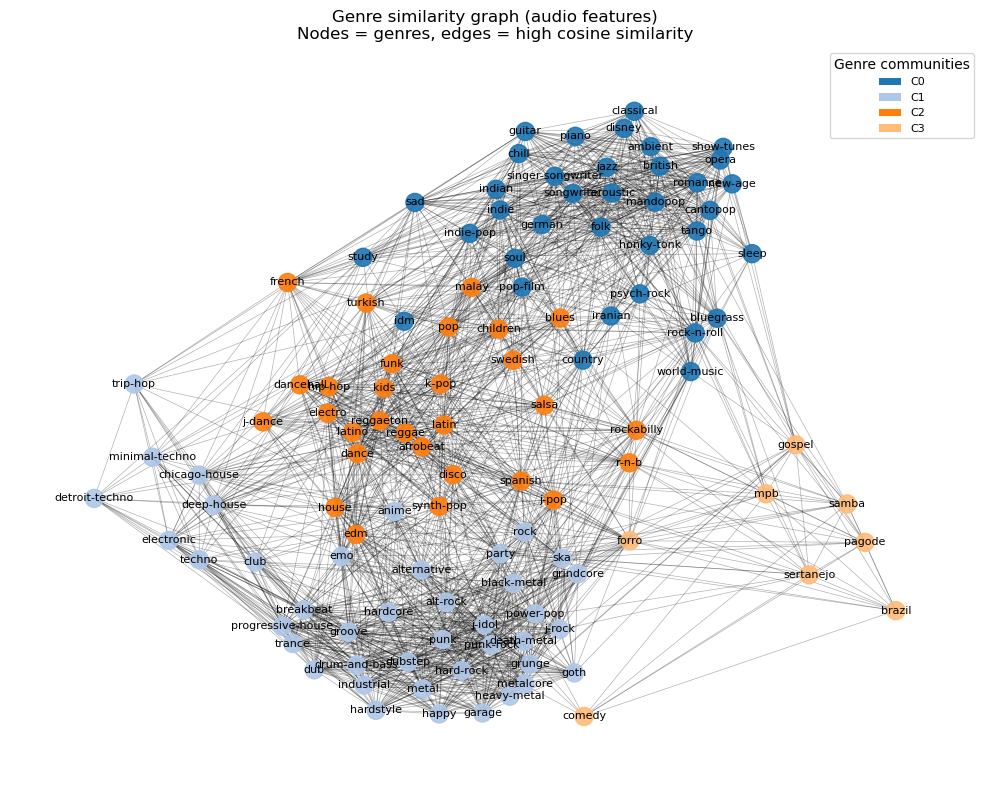

In [62]:
genres_all = df_genre_feat.index.tolist()
n_genres = len(genres_all)

# threshold for keeping edges 
SIM_THRESHOLD = 0.3

G_genre = nx.Graph()
for g in genres_all:
    G_genre.add_node(
        g,
        n_tracks=int(df_genre_feat.loc[g, "n_tracks"])
    )

edge_count = 0
for i in range(n_genres):
    for j in range(i + 1, n_genres):
        w = S_z[i, j]
        if w > SIM_THRESHOLD:
            G_genre.add_edge(genres_all[i], genres_all[j], weight=float(w))
            edge_count += 1

print(f"Genre graph: {G_genre.number_of_nodes()} nodes, {edge_count} edges "
      f"(threshold = {SIM_THRESHOLD})")

# Check connectivity of largest component 
components = list(nx.connected_components(G_genre))
components_sorted = sorted(components, key=len, reverse=True)
print(f"  Connected components: {len(components_sorted)}")
print(f"  Largest component size: {len(components_sorted[0])}")

# For community detection, we  work on the full graph
# Louvain communities on genre graph 
print("\nRunning Louvain on genre graph...")
genre_comms = louvain_communities(G_genre, weight="weight", seed=42)
print(f"  Found {len(genre_comms)} communities.")

# Modularity (weighted)
Q_genre = modularity(G_genre, genre_comms, weight="weight")
print(f"  Louvain modularity on genre graph (weighted): Q = {Q_genre:.4f}")

# Build node -> community mapping
comm_map = {}
for cid, comm in enumerate(genre_comms):
    for g in comm:
        comm_map[g] = cid

# Community size summary
sizes = [(cid, len(nodes)) for cid, nodes in enumerate(genre_comms)]
sizes_sorted = sorted(sizes, key=lambda x: x[1], reverse=True)
print("\nCommunity sizes (id, |C|):")
for cid, sz in sizes_sorted:
    print(f"  Community {cid}: {sz} genres")

# Show a few example genres per community (top 3 by n_tracks)
print("\nExample genres in each community (top by n_tracks):")
for cid, comm in sizes_sorted:
    comm_genres = list(genre_comms[cid])
    comm_df = df_genre_feat.loc[comm_genres].sort_values("n_tracks", ascending=False)
    top_names = ", ".join(comm_df.head(3).index.tolist())
    print(f"  Community {cid}: {top_names}")

# Visualisation 
print("\nPlotting genre similarity graph with communities...")

# Use only the largest component for a cleaner plot
gcc_nodes = components_sorted[0]
H = G_genre.subgraph(gcc_nodes).copy()

pos = nx.spring_layout(H, seed=42, weight="weight", k=0.5)

# Colour by community
unique_comms = sorted({comm_map[g] for g in H.nodes()})
palette = sns.color_palette("tab20", n_colors=len(unique_comms))
color_map = {cid: palette[i] for i, cid in enumerate(unique_comms)}

node_colors = [color_map[comm_map[g]] for g in H.nodes()]

# Node size ~ log(n_tracks)
sizes = []
for g in H.nodes():
    n_t = H.nodes[g]["n_tracks"]
    sizes.append(100 + 10 * np.log1p(n_t))

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(H, pos, alpha=0.3, width=0.5)
nx.draw_networkx_nodes(H, pos, node_size=sizes, node_color=node_colors, alpha=0.9)

# Label only the larger genres for readability
for g in H.nodes():
    if H.nodes[g]["n_tracks"] >= 800:  # threshold for labelling
        x, y = pos[g]
        plt.text(x, y, g, fontsize=8, ha="center", va="center")

# Legend for communities
handles = [
    Patch(facecolor=color_map[cid], edgecolor="none", label=f"C{cid}")
    for cid in unique_comms
]
plt.legend(handles=handles, title="Genre communities", loc="upper right",
           frameon=True, fontsize=8)

plt.title("Genre similarity graph (audio features)\nNodes = genres, edges = high cosine similarity")
plt.axis("off")
plt.tight_layout()
plt.show()

To move from individual tracks to a more interpretable “map of genres”, a
genre–genre similarity graph is constructed from the z-scored audio feature
vectors. Each node corresponds to one of the 114 `track_genre` labels, and an
undirected edge is added between two genres when their cosine similarity
exceeds $0.3$. The resulting graph has $114$ nodes and $1{,}949$ edges and
forms a single connected component, so every genre is linked, directly or
indirectly, to every other through chains of audio similarity. The network is
therefore fairly dense, but still leaves ample room for higher-level
structure.

Applying the Louvain algorithm to this weighted genre graph yields
$4$ communities with modularity $Q \approx 0.44$, which indicates a
moderately strong but not perfectly segregated community structure. The
communities are musically meaningful rather than arbitrary partitions. One
community is dominated by high-energy electronic and club-oriented genres such
as `minimal-techno`, `ska`, and `trance`. A second community groups more
acoustic, songwriter, and traditional material such as `honky-tonk`, `piano`,
and `singer-songwriter`. A third community collects mainstream dance and
pop-adjacent styles including `dancehall`, `edm`, and `reggae`. The smallest
community gathers more niche or region-specific genres such as `forro`,
`samba`, and `gospel`. In the spring-layout visualisation these communities
occupy overlapping but distinguishable regions, showing that genres with
similar average audio profiles cluster together, while the boundaries between
clusters remain fuzzy rather than sharply separated.

This genre-level audio similarity graph provides a compact representation of
how genres are organised in feature space. It also defines a natural reference
for the text-based part of the project where comparing the results will make it
possible to identify cases where audio similarity and lyrical similarity agree
(genres that cluster together in both spaces) and where they diverge (genres
that sound similar but differ in lyrical content, or vice versa).


In [ ]:

# # Add community id as a node attribute
for g in G_genre.nodes():
    G_genre.nodes[g]["community"] = int(comm_map[g])  # Louvain community id

# Add a layout (x, y) for each node so Gephi etc. can use it
#     (use the full graph, not only GCC, for the export)
pos_full = nx.spring_layout(G_genre, seed=42, weight="weight", k=0.5)

for g, (x, y) in pos_full.items():
    G_genre.nodes[g]["x"] = float(x)
    G_genre.nodes[g]["y"] = float(y)

# Add a size attribute based on number of tracks
for g in G_genre.nodes():
    n_t = G_genre.nodes[g].get("n_tracks", 1)
    G_genre.nodes[g]["size"] = float(100 + 10 * np.log1p(n_t))

# Add some graph-level metadata
G_genre.graph["name"] = "Spotify genre similarity graph (audio features)"
G_genre.graph["sim_threshold"] = SIM_THRESHOLD
G_genre.graph["similarity"] = "cosine on z-scored audio features"
G_genre.graph["communities"] = "Louvain, weight=similarity"

# # Write to GEXF
out_path = "spotify_genre_similarity_audio.gexf"
# nx.write_gexf(G_genre, out_path) # Uncomment this line to actually write the file
print(f"\nWrote genre similarity graph to: {out_path}")



Wrote genre similarity graph to: spotify_genre_similarity_audio.gexf


### PCA EMBEDDING OF GENRES

Explained variance by PC1+PC2: 0.575


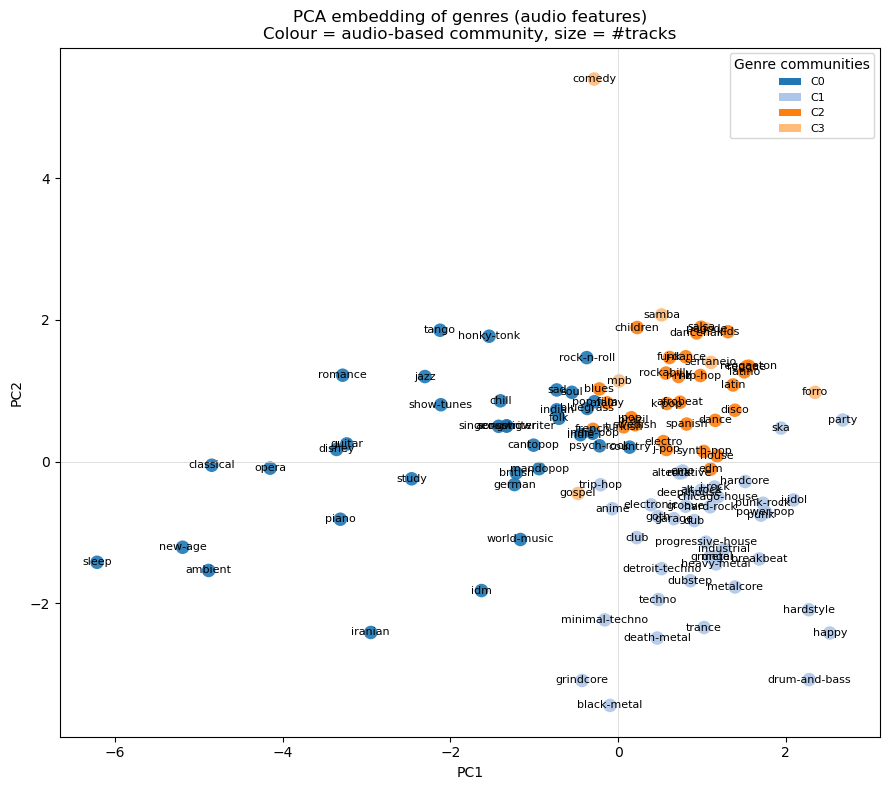

In [64]:
genres_all = df_genre_feat.index.tolist()
n_genres = len(genres_all)

# PCA on z-scored vectors
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_z)

print("Explained variance by PC1+PC2:",
      f"{pca.explained_variance_ratio_.sum():.3f}")

# Build colour map from communities
unique_comms = sorted({comm_map[g] for g in genres_all})
palette = sns.color_palette("tab20", n_colors=len(unique_comms))
color_map = {cid: palette[i] for i, cid in enumerate(unique_comms)}

colors = [color_map[comm_map[g]] for g in genres_all]

# Node size ~ log(n_tracks)
sizes = []
for g in genres_all:
    n_t = int(df_genre_feat.loc[g, "n_tracks"])
    sizes.append(40 + 8 * np.log1p(n_t))

plt.figure(figsize=(9, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            s=sizes, c=colors, alpha=0.9, edgecolors="none")

# Label only big genres for readability
for i, g in enumerate(genres_all):
    n_t = int(df_genre_feat.loc[g, "n_tracks"])
    if n_t >= 800:  # threshold for labels
        plt.text(X_pca[i, 0], X_pca[i, 1], g,
                 fontsize=8, ha="center", va="center")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA embedding of genres (audio features)\nColour = audio-based community, size = #tracks")
plt.axhline(0, color="lightgray", linewidth=0.5)
plt.axvline(0, color="lightgray", linewidth=0.5)

# Legend for communities
handles = [
    Patch(facecolor=color_map[cid], edgecolor="none", label=f"C{cid}")
    for cid in unique_comms
]
plt.legend(handles=handles, title="Genre communities", loc="upper right",
           frameon=True, fontsize=8)

plt.tight_layout()
plt.show()

Finally, we embedded the z-scored genre feature vectors into 2D using PCA. The
first two principal components together explain about **57.5%** of the total
variance, so the projection captures most of the structure present in the
audio features. When we colour each point (genre) by its audio-based Louvain
community and scale the point size by the number of tracks, the same four
communities from the genre graph reappear as partially overlapping “clouds”.
High-energy electronic and metal genres are concentrated on one side of PC1,
acoustic and ambient genres on the opposite side, while pop / dance / Latin
styles occupy a separate lobe along PC2. This confirms that the communities we
found on the genre similarity graph are not an artefact of thresholding, but
reflect coherent directions of variation in the underlying audio space.


### modularity summary table

In [65]:
# helper: modularity for a node->community mapping 
def modularity_from_partition(G, part_map, weight=None):
    comm_dict = {}
    for n, c in part_map.items():
        comm_dict.setdefault(c, set()).add(n)
    comms = list(comm_dict.values())
    return modularity(G, comms, weight=weight)

# Genre-based partition on track graph
#    rebuild mapping from track node -> its genre
G_tracks = G_gc_simple  
genre_map_nodes = {n: G_tracks.nodes[n].get("genre", "unknown")
                   for n in G_tracks.nodes()}
Q_genre_labels = modularity_from_partition(G_tracks, genre_map_nodes)

# Louvain on track graph (unweighted) + modularity
comms_track = louvain_communities(G_tracks, seed=42)
Q_louvain_tracks = modularity(G_tracks, comms_track)

# Louvain on genre graph (audio similarity)
Q_genre_graph = Q_genre  

# Build summary table
df_mod = pd.DataFrame([
    {
        "level": "tracks",
        "partition": "given genres",
        "graph": "track k-NN",
        "modularity_Q": Q_genre_labels,
    },
    {
        "level": "tracks",
        "partition": "Louvain",
        "graph": "track k-NN",
        "modularity_Q": Q_louvain_tracks,
    },
    {
        "level": "genres",
        "partition": "Louvain (audio similarity)",
        "graph": "genre similarity graph",
        "modularity_Q": Q_genre_graph,
    },
])

display(df_mod)

,level,partition,graph,modularity_Q
0,tracks,given genres,track k-NN,0.085326
1,tracks,Louvain,track k-NN,0.844723
2,genres,Louvain (audio similarity),genre similarity graph,0.443074


The modularity summary compares how well different partitions align with the
community structure of the two networks. On the track similarity network, the
partition induced by the given genre labels yields a low modularity of
$Q \approx 0.0853$, indicating that tracks sharing the same genre are only
slightly more connected than expected under a random null model. In contrast,
Louvain communities on the same track network achieve a very high modularity of
$Q \approx 0.8447$, showing that the network itself contains a strong intrinsic
community structure that is only weakly captured by the metadata genres.
At the genre level, Louvain communities on the genre–genre audio similarity
graph reach an intermediate modularity of $Q \approx 0.4431$, suggesting that
genres do form coherent groups in feature space, but these groups are broader
and less sharply separated than the track-level communities. Overall, the
table shows that the network organises tracks into well-defined structural
modules, while the declared genres provide a much coarser and only partially
aligned description of this organisation.
